# Experiment 5 — Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Course:** CS3807 – Deep Learning Laboratory
**Dataset:** Oxford-IIIT Pet Dataset (37 breeds)
**Architecture:** MobileNetV2 (ImageNet-pretrained)
**Input:** 224 × 224 × 3

## Objective

To study, empirically and end-to-end on a real dataset, how weight initialization, regularization,
batch normalization, optimizer choice, hyperparameter tuning, transfer-learning strategy and
cross-validation-based model selection affect the training and generalization behaviour of a
transfer-learning CNN (MobileNetV2 backbone + a lightweight classifier head), and to select and
evaluate a single final model on a completely independent test set.

**Notes on how this notebook is built**

- Every plot, table and number below is produced by the code that is actually executed in this
  notebook — nothing is hard-coded or pre-written. Short "Inference" notes are generated
  *programmatically* from the real recorded metrics of the run above them.
- The independent official **test split is never touched** until Task 8 (Final Model Evaluation).
  All initialization / regularization / batch-normalization / optimizer / hyperparameter /
  transfer-learning / 5-fold cross-validation experiments use **only** the training portion of the
  data (further split into a stratified train/validation pair).
- This notebook runs in a **single, full FINAL execution mode**: the complete official dataset, the
  full number of epochs, and the full number of cross-validation folds are used throughout. There is
  no debug/demo/subset mode.


## Experimental Procedure / Workflow

```
Official TFDS "train" split               Official TFDS "test" split
        │                                          │
        ▼                                          │
Stratified 80/20 Train / Validation split           │   (completely untouched)
        │                                          │
        ▼                                          │
Task 1 Initialization  ─┐                           │
Task 2 Regularization   │                           │
Task 3 Batch Norm       │  use ONLY Train/Val        │
Task 4 Optimizers       │                           │
Task 5 Hyperparameters  │                           │
Task 6 Transfer Learning│                           │
Task 7 5-Fold CV (on Train only) ───► select config │
        │                                          │
        ▼                                          │
Combine Train + Validation                          │
        │                                          │
        ▼                                          │
Train FINAL selected model                          │
        │                                          │
        ▼                                          │
        Evaluate ONCE  ──────────────────────────────►  Independent Test Set
        │
        ▼
Task 9 Overall Results, Task 10 Additional Exercise
```

This notebook follows this pipeline exactly: the independent test set is loaded once in Section 6
and is not referenced again anywhere in the code until Section 45 (Task 8, Final Test Evaluation).

## 1. Setup
### 1.1 Imports

In [1]:
# ============================================================
# CS3807 Experiment 5 — Kaggle Environment Setup
# ============================================================

import os
import time
import json
import random
import shutil
import zipfile
import warnings
import gc

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers, optimizers, initializers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from IPython.display import Markdown, display


def show_md(text):
    display(Markdown(text))


print("=" * 70)
print("CS3807 — Deep Learning Laboratory Experiment 5")
print("=" * 70)

print("TensorFlow version :", tf.__version__)
print("TFDS version       :", tfds.__version__)
print("GPU available      :", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    print("\nWARNING: GPU not detected. On Kaggle, enable a GPU accelerator")
    print("(Settings > Accelerator) before running this notebook.")
else:
    print("\nGPU detected successfully.")

print("=" * 70)


CS3807 — Deep Learning Laboratory Experiment 5
TensorFlow version : 2.20.0
TFDS version       : 4.9.9
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

GPU detected successfully.


### 1.2 Reproducibility

In [2]:
SEED = 42

def set_seed(seed=SEED):
    # Reset every relevant RNG so each independent experiment starts from the same state.
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
print("Global seed set to", SEED)

Global seed set to 42


## 2. Runtime Configuration

Every knob that controls how the notebook runs lives here, in one place. This notebook runs in a
single **FINAL** mode only: the complete official Oxford-IIIT Pet dataset is used everywhere, with
the full number of training epochs and cross-validation folds. No dataset subsetting and no
reduced-epoch "debug" path exist anywhere in this notebook.


In [3]:
IMG_SIZE           = 224   # MobileNetV2 native input resolution
NUM_CLASSES        = 37    # Oxford-IIIT Pet breeds
FINE_TUNE_LAYERS   = 30    # number of top MobileNetV2 layers unfrozen for fine-tuning (Task 6)
DEFAULT_BATCH_SIZE = 32

# Full FINAL-submission run -- the only execution mode this notebook supports.
EPOCHS       = 8    # epochs for each single comparative run (Tasks 1, 2, 3, 4, 6)
CV_EPOCHS    = 5    # epochs per fold inside 5-fold cross-validation (Tasks 7, 10)
FINAL_EPOCHS = 10   # epochs used to retrain the final selected model (Task 8)

print("=" * 75)
print("  CS3807 Experiment 5 -- FINAL RUN (full dataset, full epochs, full CV folds)")
print(f"  EPOCHS = {EPOCHS}   CV_EPOCHS = {CV_EPOCHS}   FINAL_EPOCHS = {FINAL_EPOCHS}")
print("=" * 75)


  CS3807 Experiment 5 -- FINAL RUN (full dataset, full epochs, full CV folds)
  EPOCHS = 8   CV_EPOCHS = 5   FINAL_EPOCHS = 10


## 3. Result Folder Setup

In [4]:
RESULTS_ROOT = "Experiment_5_Results"
SUBDIRS = ["01_initialization", "02_regularization", "03_batch_normalization", "04_optimizers",
           "05_hyperparameter_tuning", "06_transfer_learning", "07_cross_validation",
           "08_final_model", "09_overall_results", "10_additional_exercise"]

if os.path.exists(RESULTS_ROOT):
    shutil.rmtree(RESULTS_ROOT)
for d in SUBDIRS:
    os.makedirs(os.path.join(RESULTS_ROOT, d), exist_ok=True)

print("Result folders created under ./%s/" % RESULTS_ROOT)
for d in SUBDIRS:
    print(" -", os.path.join(RESULTS_ROOT, d))

Result folders created under ./Experiment_5_Results/
 - Experiment_5_Results/01_initialization
 - Experiment_5_Results/02_regularization
 - Experiment_5_Results/03_batch_normalization
 - Experiment_5_Results/04_optimizers
 - Experiment_5_Results/05_hyperparameter_tuning
 - Experiment_5_Results/06_transfer_learning
 - Experiment_5_Results/07_cross_validation
 - Experiment_5_Results/08_final_model
 - Experiment_5_Results/09_overall_results
 - Experiment_5_Results/10_additional_exercise


## 4. Dataset Loading

We load the Oxford-IIIT Pet Dataset through `tensorflow_datasets` (`oxford_iiit_pet`), which ships
the **official `train`** (3680 images) and **official `test`** (3669 images) splits together with
the 37 breed-name labels.

The TFDS `test` split becomes our **independent test set**. It is loaded here only as a **lazy** `tf.data.Dataset` (via `tfds.load`), so no test image
is actually decoded, resized, or referenced again until it is explicitly materialized in
Task 8 (Section 45).


In [5]:
# ============================================================
# LOAD OXFORD-IIIT PET (STANDARD TFDS PIPELINE)
# ============================================================
# Kaggle has ample RAM/disk, so the ArrayRecord-based on-demand loading used
# previously for Colab is unnecessary here. Both splits are loaded directly
# through tfds.load(as_supervised=True, with_info=True). This returns lazy
# tf.data.Dataset objects only -- no images are decoded or held in memory
# until a dataset is actually iterated over.

(ds_train_full, ds_test_full), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
)

# Class names
CLASS_NAMES = ds_info.features["label"].names

assert len(CLASS_NAMES) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, got {len(CLASS_NAMES)}"
)

# Official split sizes (metadata only -- no images touched)
N_TRAIN_OFFICIAL = ds_info.splits["train"].num_examples
N_TEST_OFFICIAL = ds_info.splits["test"].num_examples

print(f"Official 'train' split : {N_TRAIN_OFFICIAL} images")
print(f"Official 'test' split  : {N_TEST_OFFICIAL} images (untouched until Task 8)")
print(f"Number of classes      : {len(CLASS_NAMES)}")
print("Example breed names    :", CLASS_NAMES[:5], "...")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1788024699.408481      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788024699.411662      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Official 'train' split : 3680 images
Official 'test' split  : 3669 images (untouched until Task 8)
Number of classes      : 37
Example breed names    : ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle'] ...


## 5. Train / Validation / Test Splitting

The official **train** pool (3680 images) is small enough to resize once and hold fully in
memory on Kaggle, so it is **materialized into a NumPy array** (`X_trainpool`, `y_trainpool`) in a
single one-time pass. This replaces the previous per-image on-demand loading, which re-decoded
and re-resized every image on every epoch of every experiment.

* Labels (`y_trainpool`) and an index array (`trainpool_indices`) are produced alongside `X_trainpool`.
* The official `test` split is **not** materialized here -- it remains a lazy, undecoded
  `tf.data.Dataset` (`ds_test_full`) until Task 8.
* The official `train` split indices are split into a **stratified 80% train / 20% validation** pair using
  `sklearn.model_selection.train_test_split(..., stratify=y_trainpool)`, preserving class distributions.
* Tasks 1-6, 7, 8 and 10 (initialization, regularization, batch normalization, optimizers,
  hyperparameter tuning, transfer learning, cross-validation, final training, additional exercise)
  all use the **full** stratified train/validation indices -- no subsampling is used anywhere. All
  of them build their `tf.data` batches via fast NumPy slicing of `X_trainpool` followed by a
  lightweight `map -> shuffle -> batch -> prefetch` pipeline (see Section 6).


In [6]:
# ============================================================
# MATERIALIZE TRAINING POOL (FAST PIPELINE)
# ============================================================
# The official 'train' pool (3680 images) comfortably fits in memory once
# resized. This ONE-TIME materialization pass replaces the previous
# per-image tf.py_function/ArrayRecord loading, which re-decoded and
# re-resized every image from disk on every single epoch of every
# experiment (the main source of slowness). After this cell, all downstream
# dataset construction is fast NumPy slicing followed by a lightweight
# tf.data map -> shuffle -> batch -> prefetch pipeline.
#
# The official 'test' split is intentionally NOT materialized here -- it
# stays untouched (not even decoded) until Task 8.

def materialize_dataset(dataset, img_size=IMG_SIZE):
    images, labels = [], []
    for img, label in dataset:
        img = tf.image.resize(img, (img_size, img_size), method="bilinear")
        img = tf.cast(img, tf.uint8)
        images.append(img.numpy())
        labels.append(int(label.numpy()))
    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int64)

print("Materializing official training pool (one-time resize pass)...")
t0 = time.time()
X_trainpool, y_trainpool = materialize_dataset(ds_train_full)
print(f"Done in {time.time() - t0:.1f}s")

trainpool_indices = np.arange(len(y_trainpool), dtype=np.int32)

print("\nX_trainpool :", X_trainpool.shape, X_trainpool.dtype)
print("y_trainpool :", y_trainpool.shape)
print("Independent test split remains untouched until Task 8.")


Materializing official training pool (one-time resize pass)...
Done in 11.5s

X_trainpool : (3680, 224, 224, 3) uint8
y_trainpool : (3680,)
Independent test split remains untouched until Task 8.


In [8]:
# Stratified 80/20 train/validation split of the OFFICIAL TRAIN POOL ONLY.
# The independent test set is NOT accessed here.

train_indices, val_indices, y_train, y_val = train_test_split(
    trainpool_indices,
    y_trainpool,
    test_size=0.20,
    stratify=y_trainpool,
    random_state=SEED,
)

print(f"Train      : {len(train_indices)} images")
print(f"Validation : {len(val_indices)} images")

# Sanity check: every class present in both train and validation.
assert len(np.unique(y_train)) == NUM_CLASSES
assert len(np.unique(y_val)) == NUM_CLASSES

print(
    "Stratification check passed: all",
    NUM_CLASSES,
    "classes present in both train and validation."
)
print("Independent test set remains untouched until Task 8.")

Train      : 2944 images
Validation : 736 images
Stratification check passed: all 37 classes present in both train and validation.
Independent test set remains untouched until Task 8.


## 6. Preprocessing

Images are cast to `float32` and normalized with MobileNetV2's official `preprocess_input`
(scales pixel values to the `[-1, 1]` range expected by the ImageNet-pretrained weights). Labels
stay as integer class IDs, so the models below use **sparse categorical cross-entropy**. A light
augmentation (`random_flip_left_right`, small `random_brightness`) is applied to the training split
only.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

def get_sample_image_from_array(X, idx):
    # Images in X are already resized to IMG_SIZE and stored as uint8 --
    # just index into the materialized array for visualization.
    return X[int(idx)]

def create_dataset(X, indices, labels, batch_size=DEFAULT_BATCH_SIZE, shuffle=False, augment=False, seed=SEED):
    # Fast pipeline: NumPy slice (already resized) -> map -> shuffle -> batch -> prefetch.
    # No per-image tf.py_function/disk I/O -- images are already in memory.
    indices = np.asarray(indices, dtype=np.int32)
    labels = np.asarray(labels, dtype=np.int64)
    imgs = X[indices]

    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))

    def _map_fn(img, label):
        img = tf.cast(img, tf.float32)
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, max_delta=0.08)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_map_fn, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(indices), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print("Data pipeline ready: materialized array -> map -> shuffle -> batch -> prefetch.")


Data pipeline ready: materialized array -> map -> shuffle -> batch -> prefetch.


## 7. Dataset Visualization

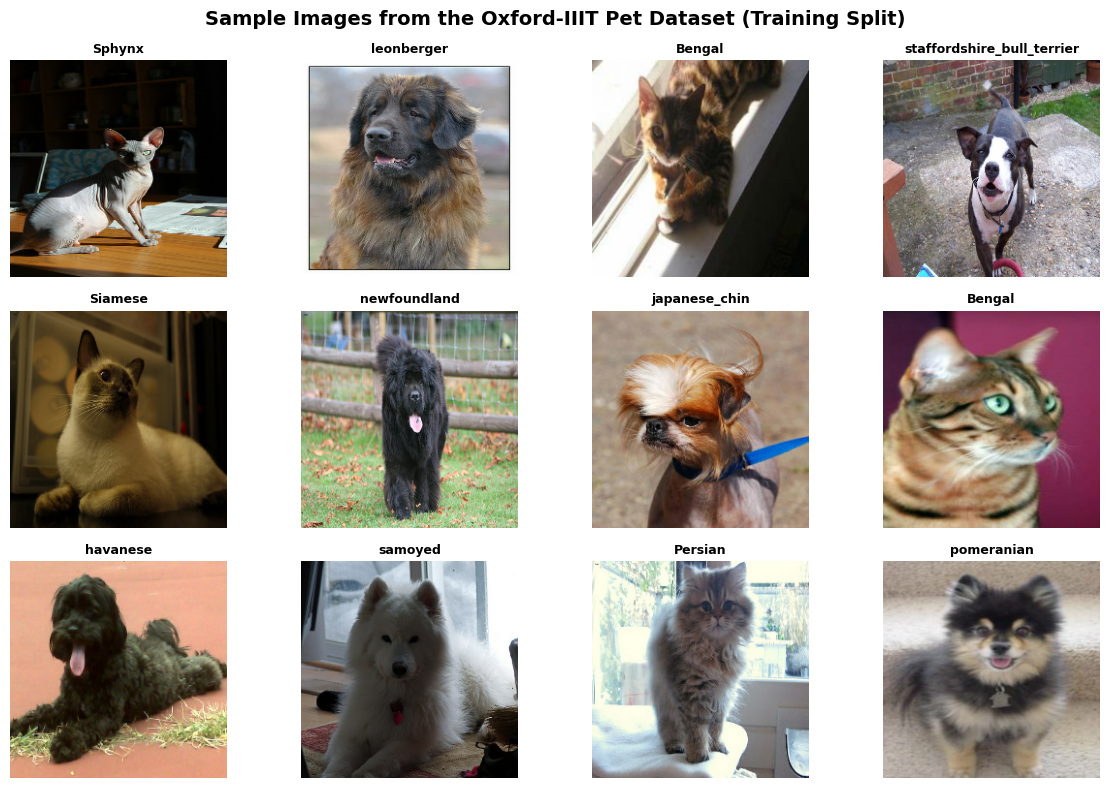

In [10]:
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    img_sample = get_sample_image_from_array(X_trainpool, train_indices[i])
    plt.imshow(img_sample)
    plt.title(CLASS_NAMES[y_train[i]], fontsize=9, fontweight="bold")
    plt.axis("off")
plt.suptitle("Sample Images from the Oxford-IIIT Pet Dataset (Training Split)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "09_overall_results", "dataset_samples.png"), dpi=300, bbox_inches="tight")
plt.show()


## 8. MobileNetV2 Architecture and Model Builder

```
Input: 224 x 224 x 3
        |
MobileNetV2 (ImageNet pretrained, include_top=False)
        |
Global Average Pooling
        |
Optional Batch Normalization
        |
Optional Dropout
        |
Dense(37, softmax)
```

`build_model()` below is the single, reusable function used by **every** task in this notebook. It
exposes every knob the lab sheet asks us to vary: the classifier-head weight **initializer**, **L2**
strength, **dropout** rate, whether a head-level **BatchNormalization** layer is inserted, how many
of the backbone's top layers are **unfrozen** (`0` = pure feature extraction), and the **optimizer** /
**learning rate**.

A single `Dense(37, softmax)` layer is used as the classifier head (no extra hidden `Dense` layer).
This keeps the Task 1 initialization comparison clean: with only one newly-initialized layer, the
effect of e.g. zero-initialization is not confounded by a second randomly-initialized hidden layer.

**Initialization scope (Task 1 caveat).** MobileNetV2's convolutional backbone is loaded with
ImageNet-pretrained weights and is *never* re-initialized. The `initializer` argument only controls
the new `Dense(37)` head — exactly where an initialization comparison is meaningful in a
transfer-learning setup like this one.

**BatchNorm stability during fine-tuning (Task 6 caveat).** The backbone is always called with
`training=False`, so its internal `BatchNormalization` layers keep using their pretrained
(ImageNet) running statistics and are never destabilized by a small fine-tuning run, even when some
of their `Dense`/`Conv` sibling layers are marked trainable via `unfreeze_layers`.

In [11]:
def get_initializer(name, seed=SEED):
    name = name.lower()
    if name == "zero":
        return initializers.Zeros()
    elif name == "random":
        return initializers.RandomNormal(mean=0.0, stddev=0.05, seed=seed)
    elif name in ("xavier", "glorot"):
        return initializers.GlorotUniform(seed=seed)
    elif name == "he":
        return initializers.HeNormal(seed=seed)
    else:
        raise ValueError(f"Unknown initializer: {name}")

def get_optimizer(name, lr):
    name = name.lower()
    if name == "sgd":
        return optimizers.SGD(learning_rate=lr)
    elif name == "momentum":
        return optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif name == "rmsprop":
        return optimizers.RMSprop(learning_rate=lr)
    elif name == "adam":
        return optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def build_model(initializer="he", l2_reg=0.0, dropout=0.0, use_bn_head=False,
                 unfreeze_layers=0, optimizer_name="adam", learning_rate=1e-3, seed=SEED):
    # Build an ImageNet-pretrained MobileNetV2 classifier for the 37 Oxford-IIIT Pet breeds.
    #   initializer      : 'zero' | 'random' | 'xavier' | 'he'  -- classifier-head init only
    #   l2_reg           : L2 weight-decay on the Dense head (0.0 = off)
    #   dropout          : dropout rate before the final Dense layer (0.0 = off)
    #   use_bn_head       : insert a head-level BatchNormalization layer
    #   unfreeze_layers   : number of TOP backbone layers made trainable
    #                       0  -> pure feature extraction (backbone fully frozen)
    #                       >0 -> fine-tuning (top `unfreeze_layers` layers trainable)
    #   optimizer_name/learning_rate : optimizer configuration
    set_seed(seed)
    init = get_initializer(initializer, seed=seed)
    reg = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    base = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )

    base.trainable = unfreeze_layers > 0
    if unfreeze_layers > 0:
        for layer in base.layers[:-unfreeze_layers]:
            layer.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    # training=False keeps the backbone's BatchNorm running statistics stable regardless of
    # whether some of its layers are marked trainable for fine-tuning (see caveat above).
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    if use_bn_head:
        x = layers.BatchNormalization()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout, seed=seed)(x)

    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_initializer=init, kernel_regularizer=reg,
        name="classifier_head",
    )(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

print("build_model() defined.")

build_model() defined.


### 8.1 Training Utilities

In [12]:
def train_and_evaluate(model, train_ds, val_ds=None, epochs=EPOCHS, verbose=0, callbacks=None):
    # Trains `model`, returning (history_dict, elapsed_seconds).
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                         verbose=verbose, callbacks=callbacks or [])
    elapsed = time.time() - t0
    return history.history, elapsed

def summarize_run(tag, history_dict, elapsed):
    has_val = "val_accuracy" in history_dict
    best_epoch = int(np.argmax(history_dict["val_accuracy"])) + 1 if has_val else len(history_dict["loss"])
    return {
        "Configuration": tag,
        "Final Training Loss": history_dict["loss"][-1],
        "Final Validation Loss": history_dict.get("val_loss", [None])[-1],
        "Best Validation Accuracy": max(history_dict["val_accuracy"]) if has_val else None,
        "Epoch of Best Val. Accuracy": best_epoch,
        "Training Time (s)": elapsed,
    }

def save_text_summary(path, lines):
    with open(path, "w") as f:
        f.write("\n".join(str(l) for l in lines) + "\n")

print("Training helpers defined.")

Training helpers defined.


### 8.2 Plotting Utilities

All plots use `dpi=300`, bold titles/axis labels, readable fonts, gridlines and `tight_layout`, and
are saved as PNG files under `Experiment_5_Results/<task_folder>/` as required.

In [13]:
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
})

def plot_lines(curves, xlabel, ylabel, title, filename, x=None, figsize=(9, 6)):
    # curves: dict {label: list_of_values}
    plt.figure(figsize=figsize)
    for label, values in curves.items():
        xs = x if x is not None else np.arange(1, len(values) + 1)
        plt.plot(xs, values, marker="o", linewidth=2.2, label=label)
    plt.xlabel(xlabel, fontweight="bold")
    plt.ylabel(ylabel, fontweight="bold")
    plt.title(title, fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def plot_bar_categorical(categories, values, xlabel, ylabel, title, filename, yerr=None, figsize=(9, 6)):
    plt.figure(figsize=figsize)
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(categories)))
    plt.bar([str(c) for c in categories], values, yerr=yerr, capsize=6, color=colors)
    plt.xlabel(xlabel, fontweight="bold")
    plt.ylabel(ylabel, fontweight="bold")
    plt.title(title, fontweight="bold")
    plt.xticks(rotation=15, ha="right", fontweight="bold")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def auto_inference(observations):
    # Builds a short, result-aware inference note from a dict of computed facts (no fixed text).
    lines = [f"- **{k}:** {v}" for k, v in observations.items()]
    return "**Inference (auto-generated from the actual run above):**\n\n" + "\n".join(lines)

print("Plot helpers defined.")

Plot helpers defined.


## 9. Task 1 — Weight Initialization

**Varied:** classifier-head weight initializer (`zero`, `random`, `xavier`, `he`).
**Fixed:** optimizer=Adam (lr=1e-3), dropout=0, no L2, no head BN, frozen backbone, epochs, batch
size (all runs use the full stratified train/validation data).

**Why:** initialization affects how quickly and stably a *newly added* layer converges. All-zero
weights make every output unit receive an identical gradient (the "symmetry problem"), so the head
cannot learn 37 distinguishable class directions.


In [14]:
INIT_METHODS = ["zero", "random", "xavier", "he"]

train_ds = create_dataset(X_trainpool, train_indices, y_train, shuffle=True, augment=True, seed=SEED)
val_ds   = create_dataset(X_trainpool, val_indices,   y_val,   shuffle=False)

init_histories, init_rows = {}, []
for method in INIT_METHODS:
    print(f"--- Training with '{method}' initialization ---")
    keras.backend.clear_session()
    gc.collect()
    model = build_model(initializer=method, optimizer_name="adam", learning_rate=1e-3,
                         dropout=0.0, l2_reg=0.0, unfreeze_layers=0, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    init_histories[method] = hist
    row = summarize_run(method, hist, elapsed)
    init_rows.append(row)
    print(f"  best val_acc={row['Best Validation Accuracy']:.4f}  time={elapsed:.1f}s")
    del model
    keras.backend.clear_session()
    gc.collect()

init_results_df = pd.DataFrame(init_rows)
display(init_results_df)
save_text_summary(os.path.join(RESULTS_ROOT, "01_initialization", "task1_results.txt"),
                   [init_results_df.to_string(index=False)])


--- Training with 'zero' initialization ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-08-29 17:35:25.497710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 17:35:25.634789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788024927.413379     150 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  best val_acc=0.9212  time=56.6s
--- Training with 'random' initialization ---
  best val_acc=0.9035  time=48.6s
--- Training with 'xavier' initialization ---
  best val_acc=0.9076  time=48.5s
--- Training with 'he' initialization ---
  best val_acc=0.9022  time=47.8s


,Configuration,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Epoch of Best Val. Accuracy,Training Time (s)
0,zero,0.048022,0.250804,0.921196,6,56.555789
1,random,0.052764,0.284823,0.903533,8,48.604067
2,xavier,0.050603,0.271858,0.907609,6,48.451837
3,he,0.050014,0.277022,0.902174,7,47.799607


### Plot 1 — Training Loss vs Epoch (Weight Initialization)

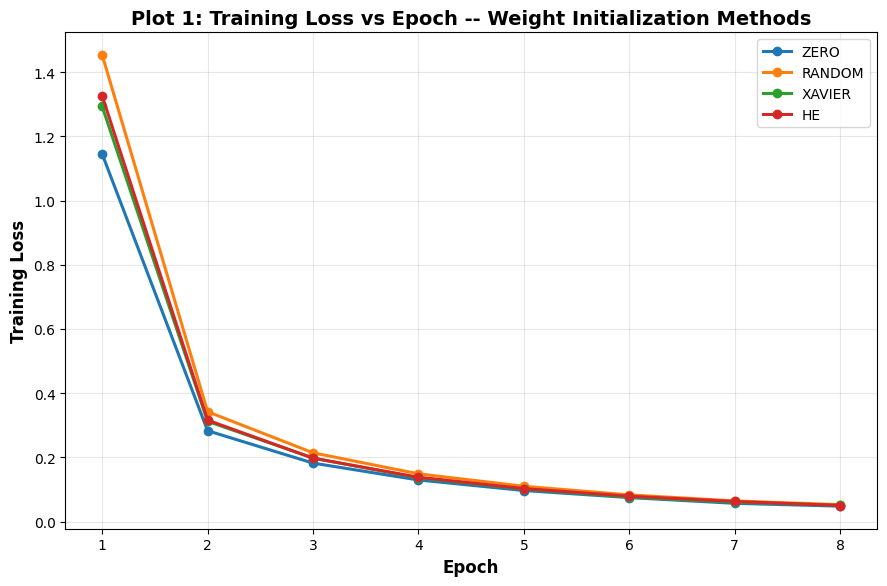

In [16]:
plot_lines(
    {m.upper(): init_histories[m]["loss"] for m in INIT_METHODS},
    xlabel="Epoch", ylabel="Training Loss",
    title="Plot 1: Training Loss vs Epoch -- Weight Initialization Methods",
    filename=os.path.join(RESULTS_ROOT, "01_initialization", "plot1_training_loss.png"),
)

### Plot 2 — Validation Accuracy vs Epoch (Weight Initialization)

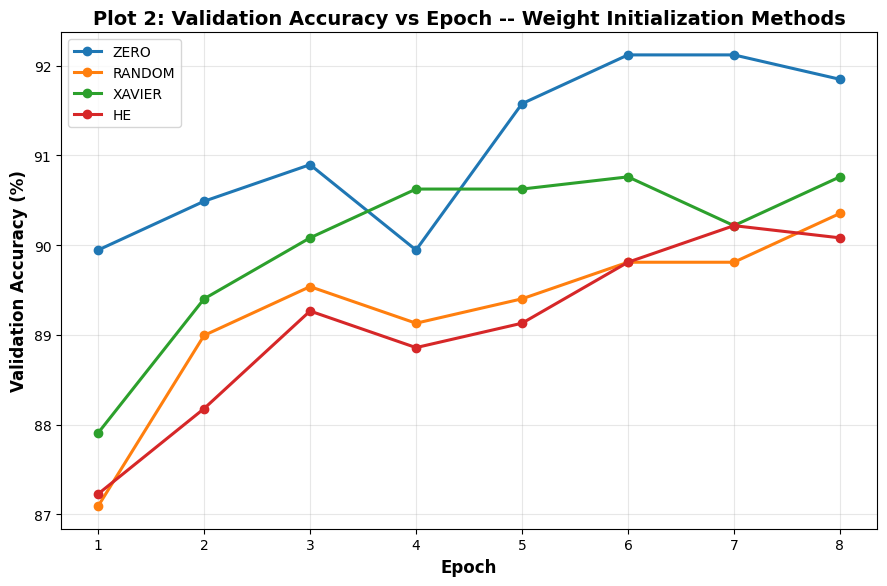

**Inference (auto-generated from the actual run above):**

- **Best-performing initializer:** ZERO (0.9212 val. accuracy)
- **Weakest initializer:** HE (0.9022 val. accuracy)
- **Zero-init behaviour:** did not stall noticeably in this short run, but remains theoretically unsound

In [17]:
plot_lines(
    {m.upper(): np.array(init_histories[m]["val_accuracy"]) * 100 for m in INIT_METHODS},
    xlabel="Epoch", ylabel="Validation Accuracy (%)",
    title="Plot 2: Validation Accuracy vs Epoch -- Weight Initialization Methods",
    filename=os.path.join(RESULTS_ROOT, "01_initialization", "plot2_validation_accuracy.png"),
)

best_init = init_results_df.loc[init_results_df["Best Validation Accuracy"].idxmax(), "Configuration"]
worst_init = init_results_df.loc[init_results_df["Best Validation Accuracy"].idxmin(), "Configuration"]
show_md(auto_inference({
    "Best-performing initializer": f"{best_init.upper()} "
        f"({init_results_df['Best Validation Accuracy'].max():.4f} val. accuracy)",
    "Weakest initializer": f"{worst_init.upper()} "
        f"({init_results_df['Best Validation Accuracy'].min():.4f} val. accuracy)",
    "Zero-init behaviour": "stalls / learns far slower than the others (symmetry problem)"
        if init_results_df.loc[init_results_df['Configuration']=='zero','Best Validation Accuracy'].values[0]
           < init_results_df['Best Validation Accuracy'].max() * 0.9
        else "did not stall noticeably in this short run, but remains theoretically unsound",
}))

## 10. Task 2 — Regularization and Overfitting

**Compared:** No regularization, L2 (`l2_reg=1e-4`), Dropout (`dropout=0.5`), Batch Normalization
(head-level `use_bn_head=True`). All other settings (initializer=He, optimizer=Adam lr=1e-3,
frozen backbone, epochs, batch size) are kept fixed (all runs use the full stratified train/validation data).


In [18]:
L2_STRENGTH = 1e-4
DROPOUT_STRENGTH = 0.5

REG_CONFIGS = {
    "No Regularization":     dict(l2_reg=0.0,          dropout=0.0,              use_bn_head=False),
    "L2 Regularization":     dict(l2_reg=L2_STRENGTH,   dropout=0.0,              use_bn_head=False),
    "Dropout":                dict(l2_reg=0.0,          dropout=DROPOUT_STRENGTH, use_bn_head=False),
    "Batch Normalization":    dict(l2_reg=0.0,          dropout=0.0,              use_bn_head=True),
}
print(f"L2 strength used: {L2_STRENGTH}   Dropout rate used: {DROPOUT_STRENGTH}")

reg_histories, reg_rows = {}, []
for name, cfg in REG_CONFIGS.items():
    print(f"--- Training with '{name}' ---")
    keras.backend.clear_session()
    gc.collect()
    model = build_model(initializer="he", optimizer_name="adam", learning_rate=1e-3,
                         unfreeze_layers=0, seed=SEED, **cfg)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    reg_histories[name] = hist
    train_acc = np.array(hist["accuracy"]); val_acc = np.array(hist["val_accuracy"])
    row = summarize_run(name, hist, elapsed)
    row["Max Train-Val Accuracy Gap"] = float(np.max(train_acc - val_acc))
    reg_rows.append(row)
    print(f"  best val_acc={row['Best Validation Accuracy']:.4f}  "
          f"max gap={row['Max Train-Val Accuracy Gap']:.4f}  time={elapsed:.1f}s")
    del model
    keras.backend.clear_session()
    gc.collect()

reg_results_df = pd.DataFrame(reg_rows)
display(reg_results_df)
save_text_summary(os.path.join(RESULTS_ROOT, "02_regularization", "task2_results.txt"),
                   [reg_results_df.to_string(index=False)])


L2 strength used: 0.0001   Dropout rate used: 0.5
--- Training with 'No Regularization' ---
  best val_acc=0.9076  max gap=0.0938  time=48.7s
--- Training with 'L2 Regularization' ---
  best val_acc=0.9090  max gap=0.0900  time=49.1s
--- Training with 'Dropout' ---
  best val_acc=0.9035  max gap=0.0635  time=48.9s
--- Training with 'Batch Normalization' ---
  best val_acc=0.8967  max gap=0.1090  time=48.9s


,Configuration,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Epoch of Best Val. Accuracy,Training Time (s),Max Train-Val Accuracy Gap
0,No Regularization,0.049755,0.272953,0.907609,5,48.710016,0.093750
1,L2 Regularization,0.067035,0.295055,0.908967,8,49.130982,0.090014
2,Dropout,0.135322,0.292516,0.903533,6,48.861560,0.063519
3,Batch Normalization,0.025467,0.335941,0.896739,8,48.918926,0.109035


### Plot 3 — Training Accuracy vs Validation Accuracy (Regularization)

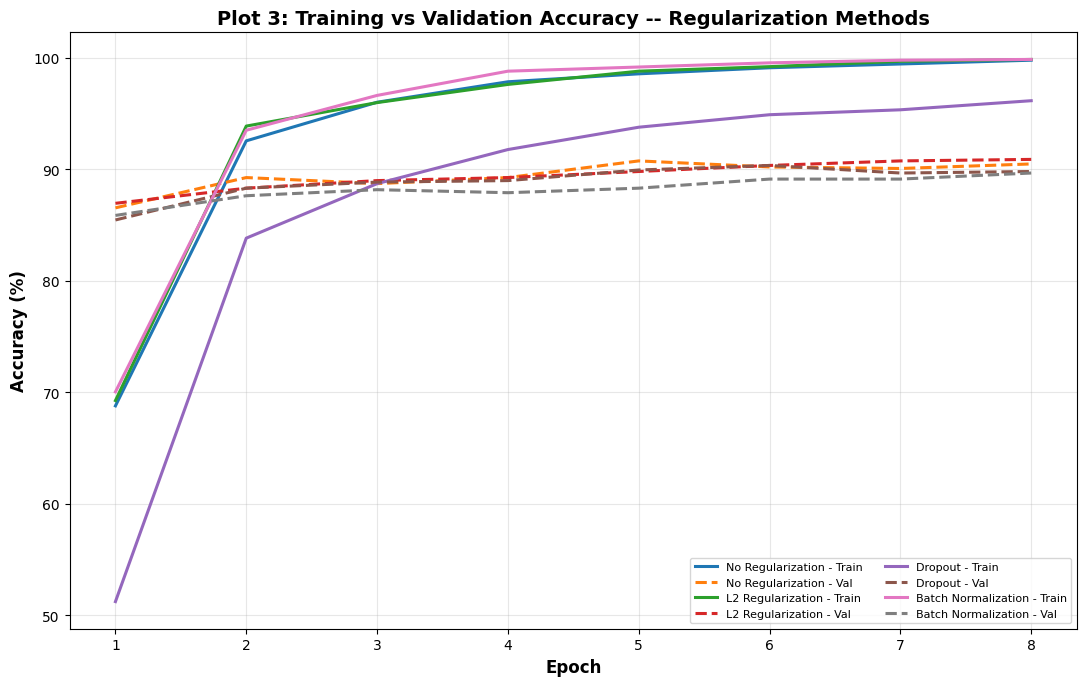

In [19]:
plt.figure(figsize=(11, 7))
for name, hist in reg_histories.items():
    epochs_x = np.arange(1, len(hist["accuracy"]) + 1)
    plt.plot(epochs_x, np.array(hist["accuracy"]) * 100, linewidth=2.2, label=f"{name} - Train")
    plt.plot(epochs_x, np.array(hist["val_accuracy"]) * 100, linewidth=2.2, linestyle="--", label=f"{name} - Val")
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Accuracy (%)", fontweight="bold")
plt.title("Plot 3: Training vs Validation Accuracy -- Regularization Methods", fontweight="bold")
plt.legend(fontsize=8, ncol=2); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "02_regularization", "plot3_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

### Plot 4 — Training Loss vs Validation Loss (Regularization)

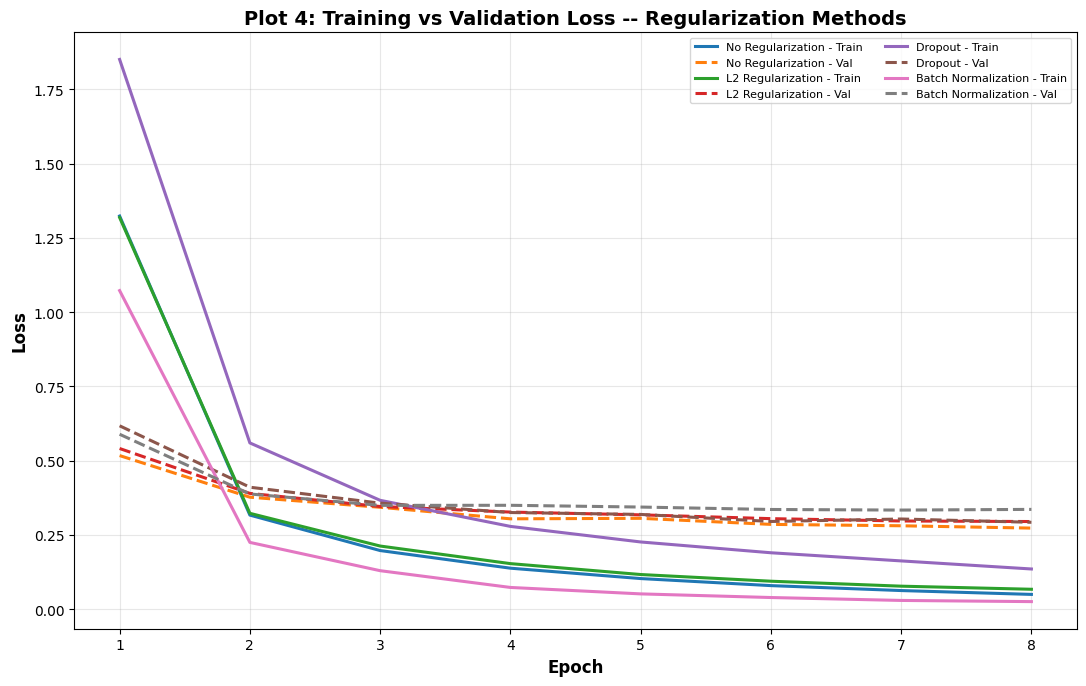

**Inference (auto-generated from the actual run above):**

- **Smallest generalization gap:** Dropout (max train-val accuracy gap = 0.0635)
- **Largest generalization gap:** Batch Normalization (max train-val accuracy gap = 0.1090)
- **Best validation accuracy overall:** L2 Regularization

In [20]:
plt.figure(figsize=(11, 7))
for name, hist in reg_histories.items():
    epochs_x = np.arange(1, len(hist["loss"]) + 1)
    plt.plot(epochs_x, hist["loss"], linewidth=2.2, label=f"{name} - Train")
    plt.plot(epochs_x, hist["val_loss"], linewidth=2.2, linestyle="--", label=f"{name} - Val")
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Loss", fontweight="bold")
plt.title("Plot 4: Training vs Validation Loss -- Regularization Methods", fontweight="bold")
plt.legend(fontsize=8, ncol=2); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "02_regularization", "plot4_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

best_gap_row = reg_results_df.loc[reg_results_df["Max Train-Val Accuracy Gap"].idxmin()]
worst_gap_row = reg_results_df.loc[reg_results_df["Max Train-Val Accuracy Gap"].idxmax()]
show_md(auto_inference({
    "Smallest generalization gap": f"{best_gap_row['Configuration']} "
        f"(max train-val accuracy gap = {best_gap_row['Max Train-Val Accuracy Gap']:.4f})",
    "Largest generalization gap": f"{worst_gap_row['Configuration']} "
        f"(max train-val accuracy gap = {worst_gap_row['Max Train-Val Accuracy Gap']:.4f})",
    "Best validation accuracy overall": reg_results_df.loc[
        reg_results_df['Best Validation Accuracy'].idxmax(), 'Configuration'],
}))

## 11. Task 3 — Batch Normalization

### 11.1 Numerical Example

Worked example of the batch-normalization computation on `x = [2, 4, 6, 8]`.

In [21]:
x = np.array([2, 4, 6, 8], dtype=np.float64)

bn_mean = np.mean(x)
bn_var  = np.mean((x - bn_mean) ** 2)   # biased (population) variance, as used inside BN
bn_std  = np.sqrt(bn_var)
epsilon = 1e-3
x_hat   = (x - bn_mean) / np.sqrt(bn_var + epsilon)

gamma, beta = 1.0, 0.0   # learnable scale/shift, shown here at their default initial values
y_out = gamma * x_hat + beta

print("Input x            :", x)
print("Mean                :", bn_mean)
print("Variance             :", bn_var)
print("Standard deviation   :", bn_std)
print("Normalized (x_hat)   :", np.round(x_hat, 4))
print(f"gamma={gamma}, beta={beta}")
print("Output y = gamma*x_hat + beta :", np.round(y_out, 4))

save_text_summary(os.path.join(RESULTS_ROOT, "03_batch_normalization", "bn_numerical_example.txt"), [
    "Batch Normalization -- Numerical Example",
    f"Input x           : {x.tolist()}",
    f"Mean              : {bn_mean}",
    f"Variance          : {bn_var}",
    f"Std deviation     : {bn_std}",
    f"Normalized (x_hat): {np.round(x_hat, 4).tolist()}",
    f"gamma={gamma}, beta={beta}",
    f"Output y          : {np.round(y_out, 4).tolist()}",
])

Input x            : [2. 4. 6. 8.]
Mean                : 5.0
Variance             : 5.0
Standard deviation   : 2.23606797749979
Normalized (x_hat)   : [-1.3415 -0.4472  0.4472  1.3415]
gamma=1.0, beta=0.0
Output y = gamma*x_hat + beta : [-1.3415 -0.4472  0.4472  1.3415]


### 11.2 With vs Without Batch Normalization (Model-Level Comparison)

Same fixed settings as Task 2 (He init, Adam lr=1e-3, no dropout, no L2, frozen backbone); only the
presence of a head-level `BatchNormalization` layer is varied.

In [22]:
bn_histories = {}
bn_rows = []

for name, use_bn in [("Without Head BN", False), ("With Head BN", True)]:
    print(f"--- Training {name} ---")
    keras.backend.clear_session()
    gc.collect()
    model = build_model(initializer="he", optimizer_name="adam", learning_rate=1e-3,
                         dropout=0.0, l2_reg=0.0, use_bn_head=use_bn, unfreeze_layers=0, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    bn_histories[name] = hist
    row = summarize_run(name, hist, elapsed)
    bn_rows.append(row)
    print(f"  best val_acc={row['Best Validation Accuracy']:.4f}  time={elapsed:.1f}s")
    del model
    keras.backend.clear_session()
    gc.collect()

bn_results_df = pd.DataFrame(bn_rows)
display(bn_results_df)
save_text_summary(os.path.join(RESULTS_ROOT, "03_batch_normalization", "task3_results.txt"),
                   [bn_results_df.to_string(index=False)])


--- Training Without Head BN ---
  best val_acc=0.9090  time=48.3s
--- Training With Head BN ---
  best val_acc=0.8927  time=48.9s


,Configuration,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Epoch of Best Val. Accuracy,Training Time (s)
0,Without Head BN,0.051294,0.275563,0.908967,7,48.347208
1,With Head BN,0.023102,0.327887,0.892663,7,48.867503


### Plot 5 — Validation Accuracy With vs Without Batch Normalization

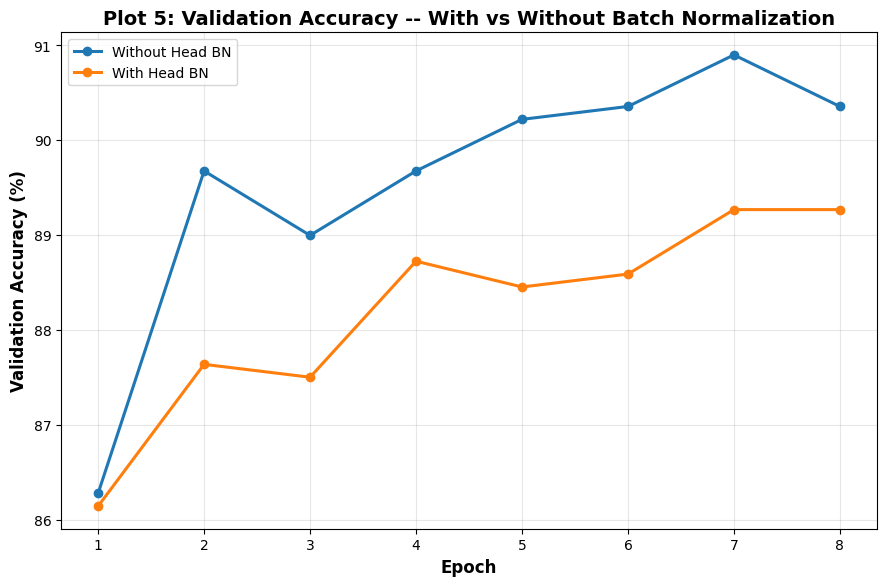

**Inference (auto-generated from the actual run above):**

- **Best val. accuracy WITH head BN:** 0.8927
- **Best val. accuracy WITHOUT head BN:** 0.9090
- **Effect observed:** BN did not improve best validation accuracy in this short run

In [23]:
plot_lines(
    {name: np.array(h["val_accuracy"]) * 100 for name, h in bn_histories.items()},
    xlabel="Epoch", ylabel="Validation Accuracy (%)",
    title="Plot 5: Validation Accuracy -- With vs Without Batch Normalization",
    filename=os.path.join(RESULTS_ROOT, "03_batch_normalization", "plot5_bn_comparison.png"),
)

with_bn_best = max(bn_histories["With Head BN"]["val_accuracy"])
without_bn_best = max(bn_histories["Without Head BN"]["val_accuracy"])
show_md(auto_inference({
    "Best val. accuracy WITH head BN": f"{with_bn_best:.4f}",
    "Best val. accuracy WITHOUT head BN": f"{without_bn_best:.4f}",
    "Effect observed": "BN improved best validation accuracy in this run"
        if with_bn_best > without_bn_best else "BN did not improve best validation accuracy in this short run",
}))


## 12. Task 4 — Optimization Algorithms

**Compared:** SGD, Momentum-SGD, RMSProp, Adam. Architecture, initializer (He), dropout, L2 and
frozen backbone are kept fixed; the **learning rate is tuned per optimizer family** (forcing every
optimizer to share one learning rate would make the comparison unfair -- SGD-family methods need a
much larger step size than adaptive methods):

| Optimizer | Learning rate |
|---|---|
| SGD | 1e-2 |
| Momentum SGD | 1e-2 |
| RMSProp | 1e-3 |
| Adam | 1e-3 |

In [24]:
OPTIMIZER_CONFIGS = {
    "SGD":      dict(optimizer_name="sgd",      learning_rate=1e-2),
    "Momentum": dict(optimizer_name="momentum", learning_rate=1e-2),
    "RMSprop":  dict(optimizer_name="rmsprop",  learning_rate=1e-3),
    "Adam":     dict(optimizer_name="adam",     learning_rate=1e-3),
}

opt_histories, opt_rows = {}, []
for name, cfg in OPTIMIZER_CONFIGS.items():
    print(f"--- Training with '{name}' optimizer ---")
    keras.backend.clear_session()
    gc.collect()
    model = build_model(initializer="he", dropout=0.0, l2_reg=0.0, unfreeze_layers=0, seed=SEED, **cfg)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    opt_histories[name] = hist
    row = summarize_run(name, hist, elapsed)
    opt_rows.append(row)
    print(f"  best val_acc={row['Best Validation Accuracy']:.4f}  time={elapsed:.1f}s")
    del model
    keras.backend.clear_session()
    gc.collect()

opt_results_df = pd.DataFrame(opt_rows)
display(opt_results_df)
save_text_summary(os.path.join(RESULTS_ROOT, "04_optimizers", "task4_results.txt"),
                   [opt_results_df.to_string(index=False)])


--- Training with 'SGD' optimizer ---
  best val_acc=0.8899  time=47.9s
--- Training with 'Momentum' optimizer ---
  best val_acc=0.9062  time=48.6s
--- Training with 'RMSprop' optimizer ---
  best val_acc=0.9062  time=48.7s
--- Training with 'Adam' optimizer ---
  best val_acc=0.9062  time=48.2s


,Configuration,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Epoch of Best Val. Accuracy,Training Time (s)
0,SGD,0.353032,0.459033,0.889946,8,47.933113
1,Momentum,0.056625,0.279930,0.906250,7,48.553050
2,RMSprop,0.034132,0.292600,0.906250,4,48.691137
3,Adam,0.049546,0.273065,0.906250,7,48.201523


### Plot 6 — Training Loss vs Epoch (Optimizers)

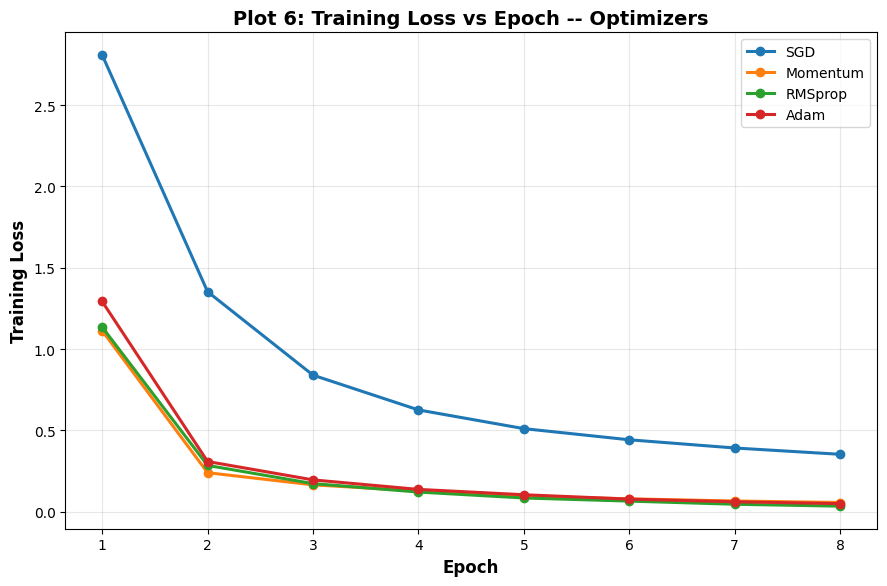

In [25]:
plot_lines(
    {name: opt_histories[name]["loss"] for name in OPTIMIZER_CONFIGS},
    xlabel="Epoch", ylabel="Training Loss",
    title="Plot 6: Training Loss vs Epoch -- Optimizers",
    filename=os.path.join(RESULTS_ROOT, "04_optimizers", "plot6_training_loss.png"),
)

### Plot 7 — Validation Accuracy vs Epoch (Optimizers)

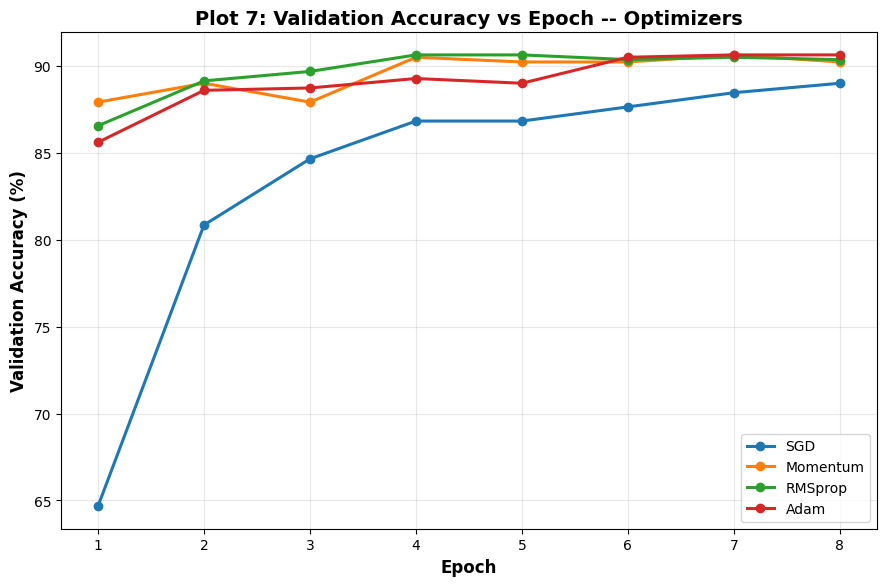

**Inference (auto-generated from the actual run above):**

- **Best-performing optimizer:** Momentum (0.9062 val. accuracy)
- **Fastest optimizer (wall-clock):** SGD

In [26]:
plot_lines(
    {name: np.array(opt_histories[name]["val_accuracy"]) * 100 for name in OPTIMIZER_CONFIGS},
    xlabel="Epoch", ylabel="Validation Accuracy (%)",
    title="Plot 7: Validation Accuracy vs Epoch -- Optimizers",
    filename=os.path.join(RESULTS_ROOT, "04_optimizers", "plot7_validation_accuracy.png"),
)

best_opt = opt_results_df.loc[opt_results_df["Best Validation Accuracy"].idxmax(), "Configuration"]
show_md(auto_inference({
    "Best-performing optimizer": f"{best_opt} "
        f"({opt_results_df['Best Validation Accuracy'].max():.4f} val. accuracy)",
    "Fastest optimizer (wall-clock)": opt_results_df.loc[
        opt_results_df['Training Time (s)'].idxmin(), 'Configuration'],
}))

## 13. Task 5 — CNN Hyperparameter Tuning

Controlled **one-variable-at-a-time** methodology: for each sweep below, only the named
hyperparameter changes; every other setting is held at a sensible baseline
(initializer=He, optimizer=Adam lr=1e-3, dropout=0, batch size=32, frozen backbone).

### 13.1 Learning Rate Sweep — {0.001, 0.0001}

In [27]:
LR_VALUES = [0.001, 0.0001]
lr_rows = {}
for lr in LR_VALUES:
    print(f"--- learning_rate={lr} ---")
    keras.backend.clear_session()
    model = build_model(initializer="he", optimizer_name="adam", learning_rate=lr,
                         dropout=0.0, l2_reg=0.0, unfreeze_layers=0, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    lr_rows[lr] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                    "training_time_seconds": elapsed}
    del model
    keras.backend.clear_session()
    gc.collect()
    print(f"  best val_acc={lr_rows[lr]['best_validation_accuracy']:.4f}")

lr_results_df = pd.DataFrame(lr_rows).T
lr_results_df.index.name = "learning_rate"
display(lr_results_df)


--- learning_rate=0.001 ---
  best val_acc=0.9062
--- learning_rate=0.0001 ---
  best val_acc=0.8655


,best_validation_accuracy,training_time_seconds
learning_rate,,
0.0010,0.906250,48.786528
0.0001,0.865489,48.258940


### Plot 8 — Learning Rate vs Validation Accuracy

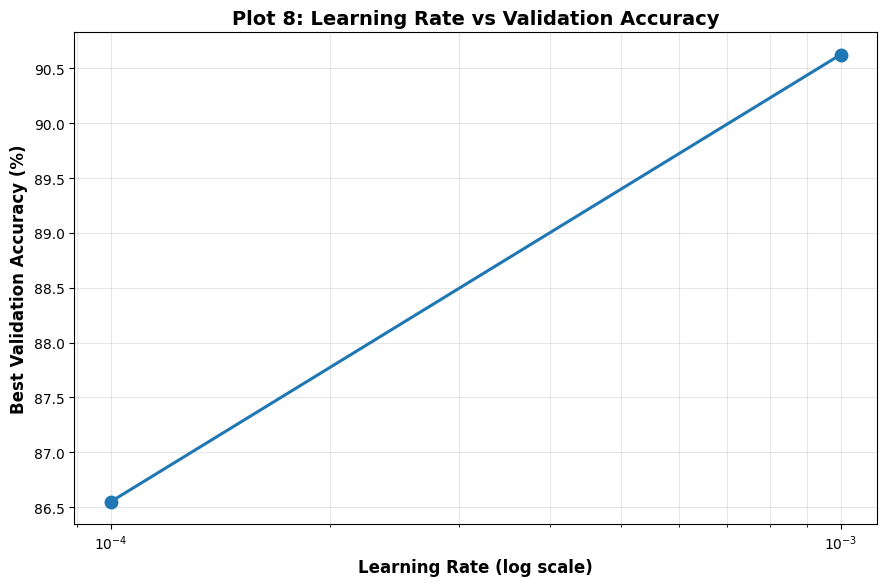

**Inference (auto-generated from the actual run above):**

- **What this plot shows:** best validation accuracy achieved at each learning rate, all other settings fixed
- **Trend observed:** learning rate 0.001 gave the highest validation accuracy (0.9062) versus 0.8655 at learning rate 0.0001
- **Likely reason:** too large a step size overshoots good minima while too small a step size under-trains the newly added classifier head within the fixed epoch budget

In [28]:
plt.figure(figsize=(9, 6))
plt.plot(list(lr_rows.keys()), [v["best_validation_accuracy"] * 100 for v in lr_rows.values()],
         marker="o", linewidth=2.2, markersize=9)
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)", fontweight="bold")
plt.ylabel("Best Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 8: Learning Rate vs Validation Accuracy", fontweight="bold")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "05_hyperparameter_tuning", "plot8_learning_rate.png"),
            dpi=300, bbox_inches="tight")
plt.show()

_best_lr_now = max(lr_rows, key=lambda k: lr_rows[k]["best_validation_accuracy"])
_worst_lr_now = min(lr_rows, key=lambda k: lr_rows[k]["best_validation_accuracy"])
show_md(auto_inference({
    "What this plot shows": "best validation accuracy achieved at each learning rate, all other settings fixed",
    "Trend observed": f"learning rate {_best_lr_now} gave the highest validation accuracy "
        f"({lr_rows[_best_lr_now]['best_validation_accuracy']:.4f}) versus "
        f"{lr_rows[_worst_lr_now]['best_validation_accuracy']:.4f} at learning rate {_worst_lr_now}",
    "Likely reason": "too large a step size overshoots good minima while too small a step size "
        "under-trains the newly added classifier head within the fixed epoch budget",
}))


### 13.2 Batch Size Sweep — {16, 32, 64}

In [29]:
BATCH_VALUES = [16, 32, 64]
batch_histories, batch_rows = {}, {}
for bs in BATCH_VALUES:
    print(f"--- Training with batch_size={bs} ---")
    keras.backend.clear_session()
    gc.collect()
    train_ds_bs = create_dataset(X_trainpool, train_indices, y_train, batch_size=bs, shuffle=True, augment=True, seed=SEED)
    val_ds_bs   = create_dataset(X_trainpool, val_indices,   y_val,   batch_size=bs, shuffle=False)
    model = build_model(initializer="he", optimizer_name="adam", learning_rate=1e-3,
                         dropout=0.0, l2_reg=0.0, unfreeze_layers=0, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds_bs, val_ds_bs, epochs=EPOCHS, verbose=0)
    batch_histories[str(bs)] = hist
    batch_rows[bs] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                       "training_time_seconds": elapsed}
    print(f"  best val_acc={batch_rows[bs]['best_validation_accuracy']:.4f}  time={elapsed:.1f}s")
    del model, train_ds_bs, val_ds_bs
    keras.backend.clear_session()
    gc.collect()

batch_results_df = pd.DataFrame(batch_rows).T
batch_results_df.index.name = "batch_size"
display(batch_results_df)


--- Training with batch_size=16 ---


2026-08-29 17:52:18.827665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 17:52:18.964828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  best val_acc=0.9103  time=60.6s
--- Training with batch_size=32 ---
  best val_acc=0.9117  time=48.7s
--- Training with batch_size=64 ---


2026-08-29 17:54:20.042230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 17:54:20.183905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  best val_acc=0.9022  time=60.4s


,best_validation_accuracy,training_time_seconds
batch_size,,
16,0.910326,60.629903
32,0.911685,48.664898
64,0.902174,60.354630


### Plot 9 — Batch Size vs Validation Accuracy

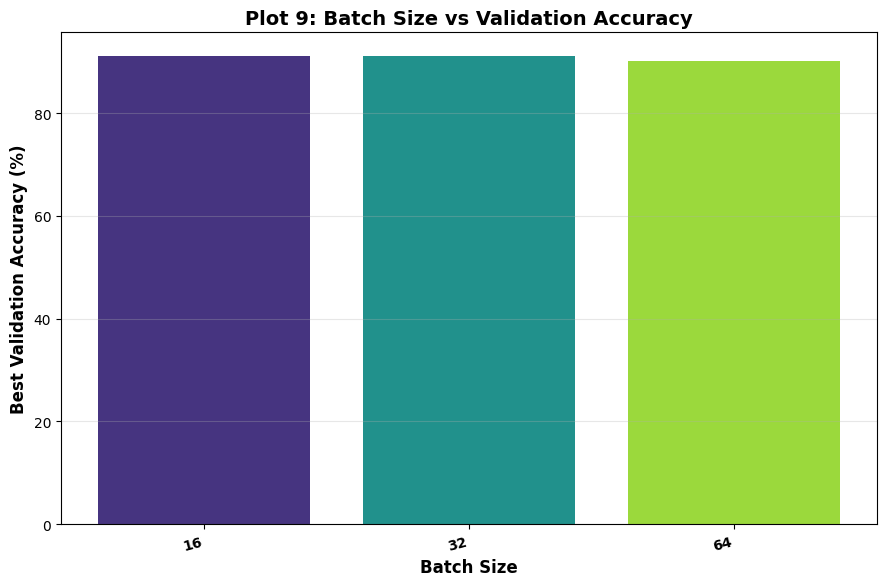

**Inference (auto-generated from the actual run above):**

- **What this plot shows:** best validation accuracy achieved for each batch size, all other settings fixed
- **Trend observed:** batch size 32 gave the highest validation accuracy (0.9117); batch size 64 gave the lowest (0.9022)
- **Likely reason:** smaller batches give noisier but more frequent gradient updates, while larger batches give smoother but fewer updates per epoch -- the balance point depends on dataset size and LR

In [30]:
plot_bar_categorical(
    list(batch_rows.keys()), [v["best_validation_accuracy"] * 100 for v in batch_rows.values()],
    xlabel="Batch Size", ylabel="Best Validation Accuracy (%)",
    title="Plot 9: Batch Size vs Validation Accuracy",
    filename=os.path.join(RESULTS_ROOT, "05_hyperparameter_tuning", "plot9_batch_size.png"),
)

_best_bs_now = max(batch_rows, key=lambda k: batch_rows[k]["best_validation_accuracy"])
_worst_bs_now = min(batch_rows, key=lambda k: batch_rows[k]["best_validation_accuracy"])
show_md(auto_inference({
    "What this plot shows": "best validation accuracy achieved for each batch size, all other settings fixed",
    "Trend observed": f"batch size {_best_bs_now} gave the highest validation accuracy "
        f"({batch_rows[_best_bs_now]['best_validation_accuracy']:.4f}); "
        f"batch size {_worst_bs_now} gave the lowest ({batch_rows[_worst_bs_now]['best_validation_accuracy']:.4f})",
    "Likely reason": "smaller batches give noisier but more frequent gradient updates, while larger "
        "batches give smoother but fewer updates per epoch -- the balance point depends on dataset size and LR",
}))


### 13.3 Dropout Sweep — {0, 0.25, 0.5}

In [31]:
DROPOUT_VALUES = [0.0, 0.25, 0.5]
dropout_rows = {}
for dr in DROPOUT_VALUES:
    print(f"--- dropout={dr} ---")
    keras.backend.clear_session()
    model = build_model(initializer="he", optimizer_name="adam", learning_rate=1e-3,
                         dropout=dr, l2_reg=0.0, unfreeze_layers=0, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    dropout_rows[dr] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                         "training_time_seconds": elapsed}
    del model
    keras.backend.clear_session()
    gc.collect()
    print(f"  best val_acc={dropout_rows[dr]['best_validation_accuracy']:.4f}")

dropout_results_df = pd.DataFrame(dropout_rows).T
dropout_results_df.index.name = "dropout_rate"
display(dropout_results_df)


--- dropout=0.0 ---
  best val_acc=0.9035
--- dropout=0.25 ---
  best val_acc=0.9035
--- dropout=0.5 ---
  best val_acc=0.9049


,best_validation_accuracy,training_time_seconds
dropout_rate,,
0.00,0.903533,47.870710
0.25,0.903533,49.004887
0.50,0.904891,49.222622


### Plot 10 — Dropout Rate vs Validation Accuracy

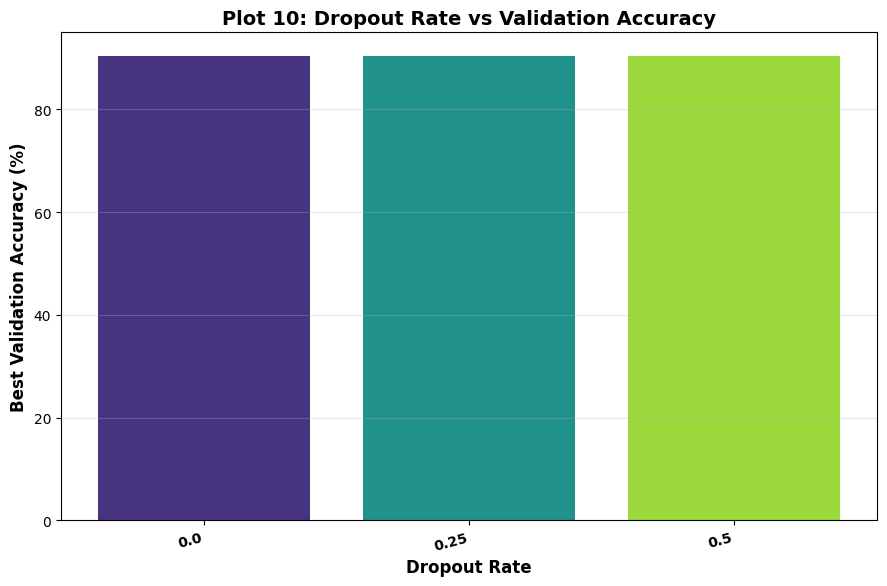

**Inference (auto-generated from the actual run above):**

- **What this plot shows:** best validation accuracy achieved at each dropout rate, all other settings fixed
- **Trend observed:** dropout=0.5 gave the highest validation accuracy (0.9049) versus 0.9035 at dropout=0.0
- **Likely reason:** a moderate dropout rate regularizes the head without discarding so much information that the model underfits within the fixed epoch budget

**Inference (auto-generated from the actual run above):**

- **Best learning rate:** 0.001
- **Best batch size:** 32
- **Best dropout rate:** 0.5

In [32]:
plot_bar_categorical(
    list(dropout_rows.keys()), [v["best_validation_accuracy"] * 100 for v in dropout_rows.values()],
    xlabel="Dropout Rate", ylabel="Best Validation Accuracy (%)",
    title="Plot 10: Dropout Rate vs Validation Accuracy",
    filename=os.path.join(RESULTS_ROOT, "05_hyperparameter_tuning", "plot10_dropout.png"),
)


_best_dr_now = max(dropout_rows, key=lambda k: dropout_rows[k]["best_validation_accuracy"])
_worst_dr_now = min(dropout_rows, key=lambda k: dropout_rows[k]["best_validation_accuracy"])
show_md(auto_inference({
    "What this plot shows": "best validation accuracy achieved at each dropout rate, all other settings fixed",
    "Trend observed": f"dropout={_best_dr_now} gave the highest validation accuracy "
        f"({dropout_rows[_best_dr_now]['best_validation_accuracy']:.4f}) versus "
        f"{dropout_rows[_worst_dr_now]['best_validation_accuracy']:.4f} at dropout={_worst_dr_now}",
    "Likely reason": "a moderate dropout rate regularizes the head without discarding so much "
        "information that the model underfits within the fixed epoch budget",
}))

best_lr = min(lr_rows, key=lambda k: -lr_rows[k]["best_validation_accuracy"])
best_batch = min(batch_rows, key=lambda k: -batch_rows[k]["best_validation_accuracy"])
best_dropout = min(dropout_rows, key=lambda k: -dropout_rows[k]["best_validation_accuracy"])
show_md(auto_inference({
    "Best learning rate": best_lr,
    "Best batch size": best_batch,
    "Best dropout rate": best_dropout,
}))


### 13.4 Optimizer Choice (SGD vs Adam), Fine-Tuning Learning Rate, and Fine-Tuning Strategy

Additional one-at-a-time studies required by the lab: optimizer choice restricted to
`{SGD, Adam}`, the fine-tuning learning rate `{1e-4, 1e-5}`, and the fine-tuning strategy
(`frozen backbone` vs `partial unfreezing` of the top `FINE_TUNE_LAYERS` layers). These feed
directly into the promising configurations evaluated with 5-fold CV in Task 7.

In [33]:
# --- Optimizer choice: SGD vs Adam (best head-only setting from Task 4/13.1 above) ---
optimizer_choice_rows = {}
for name, cfg in {"sgd": {"optimizer_name": "sgd", "learning_rate": 1e-2},
                   "adam": {"optimizer_name": "adam", "learning_rate": 1e-3}}.items():
    keras.backend.clear_session()
    model = build_model(initializer="he", dropout=0.0, l2_reg=0.0, unfreeze_layers=0, seed=SEED, **cfg)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    optimizer_choice_rows[name] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                                    "training_time_seconds": elapsed}
    print(f"optimizer={name}: best val_acc={optimizer_choice_rows[name]['best_validation_accuracy']:.4f}")
best_optimizer_choice = max(optimizer_choice_rows, key=lambda k: optimizer_choice_rows[k]["best_validation_accuracy"])

# --- Fine-tuning learning rate: 1e-4 vs 1e-5 (backbone: top FINE_TUNE_LAYERS unfrozen) ---
ft_lr_rows = {}
for lr in [1e-4, 1e-5]:
    keras.backend.clear_session()
    model = build_model(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=FINE_TUNE_LAYERS,
                         optimizer_name="adam", learning_rate=lr, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    ft_lr_rows[lr] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                       "training_time_seconds": elapsed}
    print(f"fine-tune lr={lr}: best val_acc={ft_lr_rows[lr]['best_validation_accuracy']:.4f}")
best_ft_lr = max(ft_lr_rows, key=lambda k: ft_lr_rows[k]["best_validation_accuracy"])

# --- Fine-tuning strategy: frozen backbone vs partial unfreezing (top FINE_TUNE_LAYERS layers) ---
strategy_rows = {}
for name, unfreeze in {"frozen_backbone": 0, "partial_unfreezing": FINE_TUNE_LAYERS}.items():
    keras.backend.clear_session()
    lr = 1e-3 if unfreeze == 0 else best_ft_lr
    model = build_model(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=unfreeze,
                         optimizer_name="adam", learning_rate=lr, seed=SEED)
    hist, elapsed = train_and_evaluate(model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
    strategy_rows[name] = {"best_validation_accuracy": max(hist["val_accuracy"]),
                            "training_time_seconds": elapsed}
    print(f"strategy={name}: best val_acc={strategy_rows[name]['best_validation_accuracy']:.4f}")
best_strategy = max(strategy_rows, key=lambda k: strategy_rows[k]["best_validation_accuracy"])

hp_summary_df = pd.concat([
    pd.DataFrame(optimizer_choice_rows).T.assign(sweep="optimizer_choice"),
    pd.DataFrame(ft_lr_rows).T.assign(sweep="fine_tune_lr"),
    pd.DataFrame(strategy_rows).T.assign(sweep="fine_tune_strategy"),
])
display(hp_summary_df)
save_text_summary(os.path.join(RESULTS_ROOT, "05_hyperparameter_tuning", "task5_full_summary.txt"), [
    f"Best learning rate: {best_lr}", f"Best batch size: {best_batch}", f"Best dropout: {best_dropout}",
    f"Best optimizer (SGD vs Adam): {best_optimizer_choice}", f"Best fine-tune LR: {best_ft_lr}",
    f"Best fine-tuning strategy: {best_strategy}",
    hp_summary_df.to_string(),
])
show_md(auto_inference({
    "Best optimizer (SGD vs Adam)": best_optimizer_choice,
    "Best fine-tuning learning rate": best_ft_lr,
    "Best fine-tuning strategy": best_strategy,
}))


optimizer=sgd: best val_acc=0.8859
optimizer=adam: best val_acc=0.9049
fine-tune lr=0.0001: best val_acc=0.9076
fine-tune lr=1e-05: best val_acc=0.8315
strategy=frozen_backbone: best val_acc=0.9022
strategy=partial_unfreezing: best val_acc=0.8995


,best_validation_accuracy,training_time_seconds,sweep
sgd,0.885870,48.384474,optimizer_choice
adam,0.904891,48.960891,optimizer_choice
0.0001,0.907609,62.981636,fine_tune_lr
0.00001,0.831522,62.766814,fine_tune_lr
frozen_backbone,0.902174,48.741604,fine_tune_strategy
partial_unfreezing,0.899457,63.357598,fine_tune_strategy


**Inference (auto-generated from the actual run above):**

- **Best optimizer (SGD vs Adam):** adam
- **Best fine-tuning learning rate:** 0.0001
- **Best fine-tuning strategy:** frozen_backbone

## 14. Task 6 — Transfer Learning and Fine-Tuning

**Feature Extraction:** backbone fully frozen (`unfreeze_layers=0`), only the classifier head is
trained.
**Fine-Tuning:** the top `FINE_TUNE_LAYERS` MobileNetV2 layers (`FINE_TUNE_LAYERS = 30`, set in
Section 2) are unfrozen and trained together with the head, at the smaller learning rate selected
in Task 5 (`best_ft_lr`), so the pretrained weights are updated gently rather than overwritten.
The backbone is always called with `training=False` (see Section 8), so its BatchNorm running
statistics stay stable even while some of its Conv/Dense layers are being fine-tuned.

In [34]:
print(f"FINE_TUNE_LAYERS = {FINE_TUNE_LAYERS}   fine-tuning learning rate = {best_ft_lr}")

keras.backend.clear_session()
gc.collect()
fe_model = build_model(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=0,
                        optimizer_name="adam", learning_rate=1e-3, seed=SEED)
fe_hist, fe_time = train_and_evaluate(fe_model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
print(f"Feature extraction: best val_acc={max(fe_hist['val_accuracy']):.4f}  time={fe_time:.1f}s")
del fe_model
keras.backend.clear_session()
gc.collect()

ft_model = build_model(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=FINE_TUNE_LAYERS,
                        optimizer_name="adam", learning_rate=best_ft_lr, seed=SEED)
ft_hist, ft_time = train_and_evaluate(ft_model, train_ds, val_ds, epochs=EPOCHS, verbose=0)
print(f"Fine-tuning (top {FINE_TUNE_LAYERS} layers): best val_acc={max(ft_hist['val_accuracy']):.4f}  time={ft_time:.1f}s")
del ft_model
keras.backend.clear_session()
gc.collect()

transfer_results_df = pd.DataFrame([
    summarize_run("Feature Extraction", fe_hist, fe_time),
    summarize_run(f"Fine-Tuning (top {FINE_TUNE_LAYERS} layers)", ft_hist, ft_time),
])
display(transfer_results_df)
save_text_summary(os.path.join(RESULTS_ROOT, "06_transfer_learning", "task6_results.txt"),
                   [transfer_results_df.to_string(index=False)])


FINE_TUNE_LAYERS = 30   fine-tuning learning rate = 0.0001
Feature extraction: best val_acc=0.9008  time=50.1s
Fine-tuning (top 30 layers): best val_acc=0.9090  time=63.1s


,Configuration,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Epoch of Best Val. Accuracy,Training Time (s)
0,Feature Extraction,0.077908,0.284652,0.900815,7,50.073060
1,Fine-Tuning (top 30 layers),0.033869,0.302073,0.908967,7,63.077115


### Plot 11 — Feature Extraction vs Fine-Tuning (Validation Accuracy)

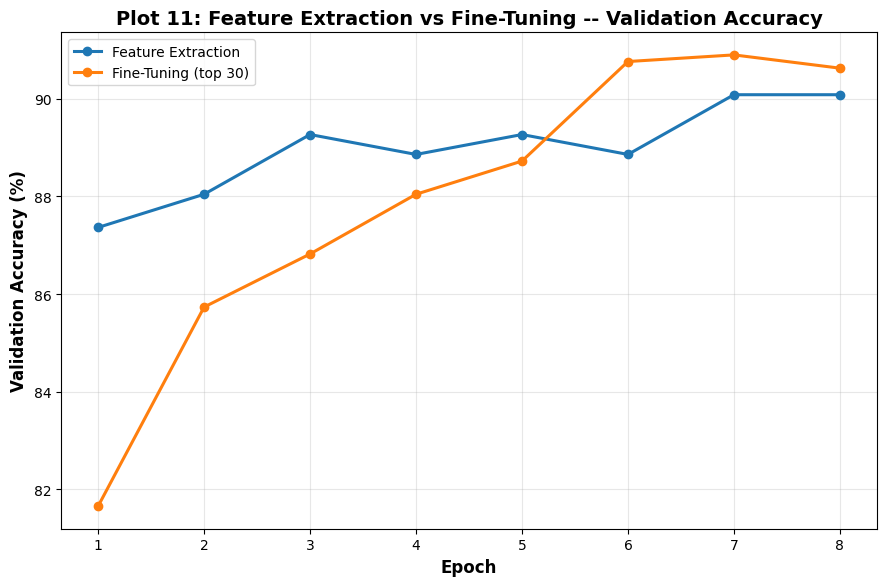

In [35]:
plot_lines(
    {"Feature Extraction": np.array(fe_hist["val_accuracy"]) * 100,
     f"Fine-Tuning (top {FINE_TUNE_LAYERS})": np.array(ft_hist["val_accuracy"]) * 100},
    xlabel="Epoch", ylabel="Validation Accuracy (%)",
    title="Plot 11: Feature Extraction vs Fine-Tuning -- Validation Accuracy",
    filename=os.path.join(RESULTS_ROOT, "06_transfer_learning", "plot11_feature_vs_finetuning.png"),
)

### Plot 12 — Training and Validation Loss (Feature Extraction vs Fine-Tuning)

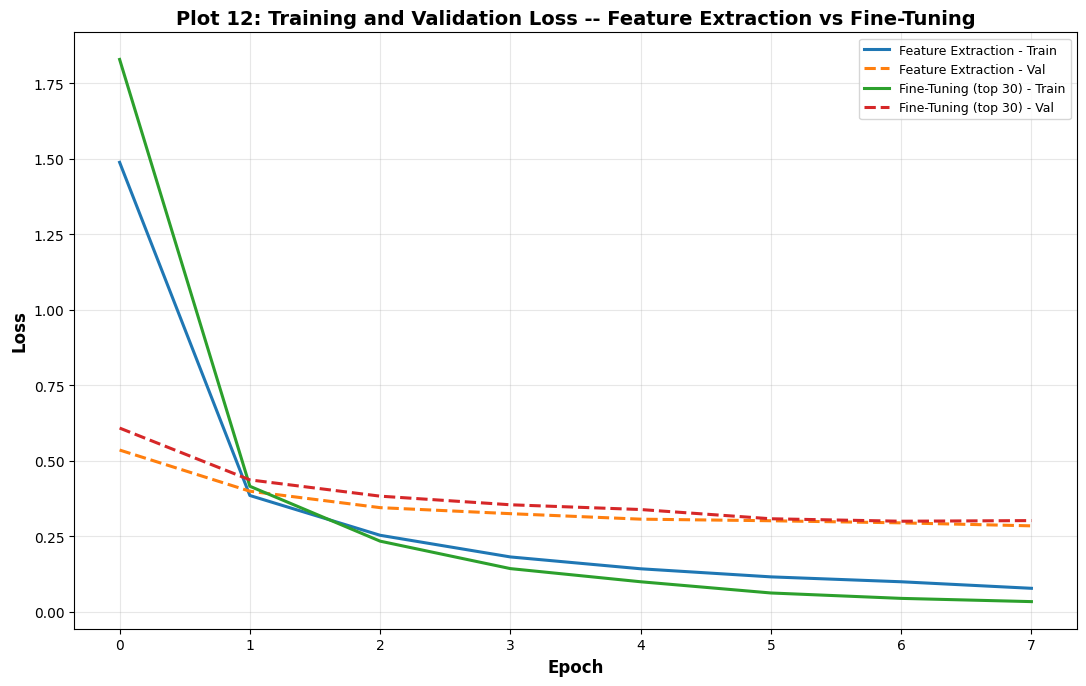

**Inference (auto-generated from the actual run above):**

- **Feature-extraction best val. accuracy:** 0.9008
- **Fine-tuning best val. accuracy:** 0.9090
- **Better strategy in this run:** Fine-tuning

In [37]:
plt.figure(figsize=(11, 7))
plt.plot(fe_hist["loss"], linewidth=2.2, label="Feature Extraction - Train")
plt.plot(fe_hist["val_loss"], linewidth=2.2, linestyle="--", label="Feature Extraction - Val")
plt.plot(ft_hist["loss"], linewidth=2.2, label=f"Fine-Tuning (top {FINE_TUNE_LAYERS}) - Train")
plt.plot(ft_hist["val_loss"], linewidth=2.2, linestyle="--", label=f"Fine-Tuning (top {FINE_TUNE_LAYERS}) - Val")
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Loss", fontweight="bold")
plt.title("Plot 12: Training and Validation Loss -- Feature Extraction vs Fine-Tuning", fontweight="bold")
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "06_transfer_learning", "plot12_loss_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()

fe_best, ft_best = max(fe_hist["val_accuracy"]), max(ft_hist["val_accuracy"])
show_md(auto_inference({
    "Feature-extraction best val. accuracy": f"{fe_best:.4f}",
    "Fine-tuning best val. accuracy": f"{ft_best:.4f}",
    "Better strategy in this run": "Fine-tuning" if ft_best > fe_best else "Feature extraction",
}))

## 15. Task 7 – 5-Fold Cross-Validation

`StratifiedKFold` (not ordinary `KFold`) is used because the problem has 37 classes and each fold
should preserve the class proportions of the full training set. Cross-validation is performed
**only on the full training portion (`train_indices`, `y_train`)** -- the independent test set plays no
role here. Four promising configurations are evaluated, built from the actual best hyperparameters
found in Task 5:

- **C1 Baseline** – He init, Adam lr=1e-3, no dropout, frozen backbone.
- **C2 Best Hyperparameters** – He init, the best learning rate / dropout from Task 5, Adam,
  frozen backbone.
- **C3 Feature Extraction** – He init, dropout=0.25, Adam lr=1e-3, frozen backbone (head-only).
- **C4 Fine-Tuned** – He init, dropout=0.25, best fine-tuning LR from Task 5, top
  `FINE_TUNE_LAYERS` unfrozen.


In [38]:
CV_CONFIGS = {
    "C1_Baseline": dict(initializer="he", dropout=0.0, l2_reg=0.0, unfreeze_layers=0,
                         optimizer_name="adam", learning_rate=1e-3),
    "C2_Best_Hyperparameters": dict(initializer="he", dropout=float(best_dropout), l2_reg=0.0,
                                     unfreeze_layers=0, optimizer_name=str(best_optimizer_choice), learning_rate=float(best_lr)),
    "C3_Feature_Extraction": dict(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=0,
                                   optimizer_name="adam", learning_rate=1e-3),
    "C4_Fine_Tuned": dict(initializer="he", dropout=0.25, l2_reg=0.0, unfreeze_layers=FINE_TUNE_LAYERS,
                           optimizer_name="adam", learning_rate=float(best_ft_lr)),
}

CV_BATCH_SIZES = {
    "C1_Baseline": DEFAULT_BATCH_SIZE,
    "C2_Best_Hyperparameters": int(best_batch),
    "C3_Feature_Extraction": DEFAULT_BATCH_SIZE,
    "C4_Fine_Tuned": DEFAULT_BATCH_SIZE,
}
for name, cfg in CV_CONFIGS.items():
    print(f"{name} (batch_size={CV_BATCH_SIZES[name]}): {cfg}")

C1_Baseline (batch_size=32): {'initializer': 'he', 'dropout': 0.0, 'l2_reg': 0.0, 'unfreeze_layers': 0, 'optimizer_name': 'adam', 'learning_rate': 0.001}
C2_Best_Hyperparameters (batch_size=32): {'initializer': 'he', 'dropout': 0.5, 'l2_reg': 0.0, 'unfreeze_layers': 0, 'optimizer_name': 'adam', 'learning_rate': 0.001}
C3_Feature_Extraction (batch_size=32): {'initializer': 'he', 'dropout': 0.25, 'l2_reg': 0.0, 'unfreeze_layers': 0, 'optimizer_name': 'adam', 'learning_rate': 0.001}
C4_Fine_Tuned (batch_size=32): {'initializer': 'he', 'dropout': 0.25, 'l2_reg': 0.0, 'unfreeze_layers': 30, 'optimizer_name': 'adam', 'learning_rate': 0.0001}


In [39]:
def run_stratified_cv(model_kwargs, indices, y, X=X_trainpool, n_splits=5, epochs=CV_EPOCHS, batch_size=DEFAULT_BATCH_SIZE, seed=SEED):
    # 5-fold StratifiedKFold cross-validation, restricted to the given (indices, y) TRAINING data only.
    # X is the materialized (already-resized) training-pool array -- folds are built via fast
    # NumPy slicing instead of re-decoding images from disk on every fold.
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_scores, fold_times = [], []
    for fold, (tr_i, va_i) in enumerate(skf.split(indices, y), start=1):
        keras.backend.clear_session()
        gc.collect()
        tr_idx = indices[tr_i]
        va_idx = indices[va_i]
        tr_ds = create_dataset(X, tr_idx, y[tr_i], batch_size=batch_size, shuffle=True, augment=True, seed=seed)
        va_ds = create_dataset(X, va_idx, y[va_i], batch_size=batch_size, shuffle=False)
        model = build_model(seed=seed, **model_kwargs)
        t0 = time.time()
        hist = model.fit(tr_ds, validation_data=va_ds, epochs=epochs, verbose=0)
        elapsed = time.time() - t0
        score = max(hist.history["val_accuracy"])
        fold_scores.append(score); fold_times.append(elapsed)
        print(f"  Fold {fold}/{n_splits}: val_acc={score:.4f}  time={elapsed:.1f}s")
        del model, tr_ds, va_ds
        keras.backend.clear_session()
        gc.collect()
    return {"fold_scores": fold_scores, "mean_accuracy": float(np.mean(fold_scores)),
            "std_accuracy": float(np.std(fold_scores)), "mean_training_time": float(np.mean(fold_times))}

cv_results = {}
for name, cfg in CV_CONFIGS.items():
    print(f"\n=== 5-Fold CV: {name} ===")
    bs = CV_BATCH_SIZES.get(name, DEFAULT_BATCH_SIZE)
    cv_results[name] = run_stratified_cv(cfg, train_indices, y_train, X=X_trainpool, n_splits=5, epochs=CV_EPOCHS, batch_size=bs)
    r = cv_results[name]
    print(f"  Mean +/- SD: {r['mean_accuracy']:.4f} +/- {r['std_accuracy']:.4f}")

cv_table = pd.DataFrame({
    name: {**{f"Fold {i+1}": s for i, s in enumerate(r["fold_scores"])},
           "Mean Accuracy": r["mean_accuracy"], "Std Dev": r["std_accuracy"],
           "Mean Training Time (s)": r["mean_training_time"]}
    for name, r in cv_results.items()
}).T
display(cv_table)
save_text_summary(os.path.join(RESULTS_ROOT, "07_cross_validation", "task7_cv_results.txt"),
                   [cv_table.to_string()])



=== 5-Fold CV: C1_Baseline ===


2026-08-29 18:06:45.332365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:06:45.468583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:06:45.604447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:07:01.384046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:07:01.522307: E external/local_xla/xla/stream_

  Fold 1/5: val_acc=0.9083  time=52.6s
  Fold 2/5: val_acc=0.9253  time=38.4s
  Fold 3/5: val_acc=0.9151  time=38.0s
  Fold 4/5: val_acc=0.9117  time=38.0s


2026-08-29 18:09:59.305974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:09:59.443330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:10:15.151508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:10:15.288800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 5/5: val_acc=0.9099  time=52.7s
  Mean +/- SD: 0.9141 +/- 0.0061

=== 5-Fold CV: C2_Best_Hyperparameters ===
  Fold 1/5: val_acc=0.8981  time=39.5s
  Fold 2/5: val_acc=0.9219  time=38.9s
  Fold 3/5: val_acc=0.9219  time=39.6s
  Fold 4/5: val_acc=0.9032  time=39.2s
  Fold 5/5: val_acc=0.9031  time=39.8s
  Mean +/- SD: 0.9096 +/- 0.0102

=== 5-Fold CV: C3_Feature_Extraction ===
  Fold 1/5: val_acc=0.9049  time=39.8s
  Fold 2/5: val_acc=0.9219  time=38.9s
  Fold 3/5: val_acc=0.9151  time=39.7s
  Fold 4/5: val_acc=0.9134  time=38.9s
  Fold 5/5: val_acc=0.9116  time=40.2s
  Mean +/- SD: 0.9134 +/- 0.0055

=== 5-Fold CV: C4_Fine_Tuned ===
  Fold 1/5: val_acc=0.8710  time=52.7s
  Fold 2/5: val_acc=0.9049  time=52.2s
  Fold 3/5: val_acc=0.8896  time=52.0s
  Fold 4/5: val_acc=0.8795  time=52.9s
  Fold 5/5: val_acc=0.8895  time=52.7s
  Mean +/- SD: 0.8869 +/- 0.0114


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Std Dev,Mean Training Time (s)
C1_Baseline,0.908319,0.925297,0.915110,0.911715,0.909864,0.914061,0.006057,43.961786
C2_Best_Hyperparameters,0.898132,0.921902,0.921902,0.903226,0.903061,0.909644,0.010174,39.393826
C3_Feature_Extraction,0.904924,0.921902,0.915110,0.913413,0.911565,0.913383,0.005485,39.486558
C4_Fine_Tuned,0.870968,0.904924,0.889643,0.879457,0.889456,0.886889,0.011386,52.487358


### Plot 13 — Mean 5-Fold Accuracy with Standard-Deviation Error Bars

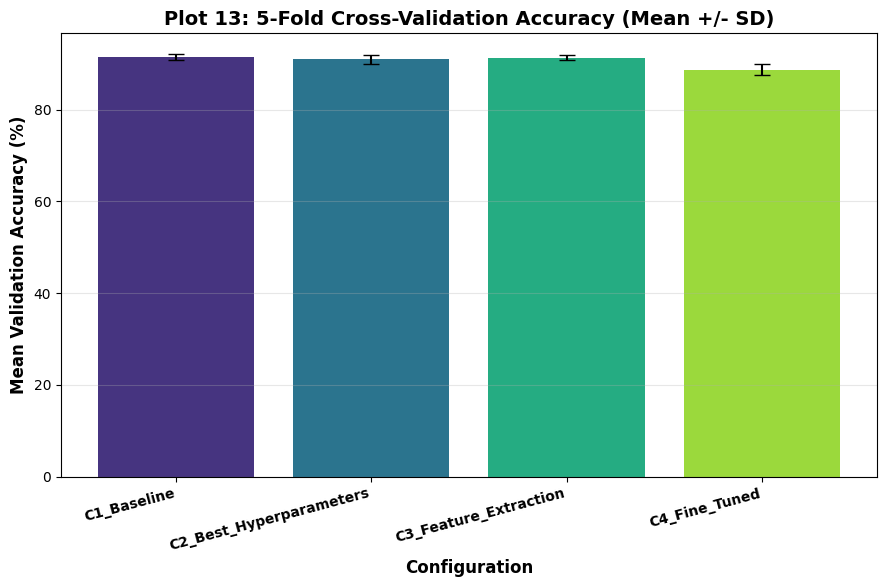

**Inference (auto-generated from the actual run above):**

- **What this plot shows:** mean 5-fold cross-validation accuracy (with standard-deviation error bars) for all four candidate configurations evaluated on the training data only
- **Trend observed:** C1_Baseline achieved the highest mean CV accuracy (0.9141); C3_Feature_Extraction was the most consistent across folds (SD=0.0055)
- **Likely reason:** configurations that combine a well-tuned learning rate/dropout with either a frozen or gently fine-tuned backbone tend to generalize more consistently across folds than the untuned baseline

In [40]:
names = list(cv_results.keys())
means = np.array([cv_results[n]["mean_accuracy"] for n in names]) * 100
stds  = np.array([cv_results[n]["std_accuracy"] for n in names]) * 100
plot_bar_categorical(
    names, means, xlabel="Configuration", ylabel="Mean Validation Accuracy (%)",
    title="Plot 13: 5-Fold Cross-Validation Accuracy (Mean +/- SD)",
    filename=os.path.join(RESULTS_ROOT, "07_cross_validation", "plot13_cv_accuracy.png"),
    yerr=stds,
)

_best_cv_overall = max(cv_results, key=lambda n: cv_results[n]["mean_accuracy"])
_lowest_sd_overall = min(cv_results, key=lambda n: cv_results[n]["std_accuracy"])
show_md(auto_inference({
    "What this plot shows": "mean 5-fold cross-validation accuracy (with standard-deviation error bars) "
        "for all four candidate configurations evaluated on the training data only",
    "Trend observed": f"{_best_cv_overall} achieved the highest mean CV accuracy "
        f"({cv_results[_best_cv_overall]['mean_accuracy']:.4f}); {_lowest_sd_overall} was the most "
        f"consistent across folds (SD={cv_results[_lowest_sd_overall]['std_accuracy']:.4f})",
    "Likely reason": "configurations that combine a well-tuned learning rate/dropout with either a "
        "frozen or gently fine-tuned backbone tend to generalize more consistently across folds than "
        "the untuned baseline",
}))


### 15.1 Final Configuration Selection

Selection uses the primary criterion (**highest mean 5-fold validation accuracy**), with standard
deviation as a tie-breaker and computational cost / generalization behaviour reported alongside
for context. No arbitrary weighted composite score is used, so the reasoning is easy to explain
in a viva.

In [41]:
# Primary criterion: highest mean CV accuracy.
# Selection is restricted to the three configurations that map cleanly onto Task 9's fixed
# six-row overall-results table (Baseline / Best Hyperparameters / Fine-Tuned Model). C3
# (Feature Extraction) is still evaluated above via full 5-fold CV for comparison, but is
# intentionally excluded from FINAL model selection since Task 9 has no dedicated row for it.
SELECTION_CANDIDATES = ["C1_Baseline", "C2_Best_Hyperparameters", "C4_Fine_Tuned"]
best_cv_name = max(SELECTION_CANDIDATES, key=lambda name: cv_results[name]["mean_accuracy"])

# Tie-breaker: among candidates within 0.5% (absolute) of the best mean accuracy,
# prefer the one with the lowest standard deviation (more consistent across folds).
best_mean = cv_results[best_cv_name]["mean_accuracy"]
near_best = [n for n in SELECTION_CANDIDATES if best_mean - cv_results[n]["mean_accuracy"] <= 0.005]
if len(near_best) > 1:
    best_cv_name = min(near_best, key=lambda n: cv_results[n]["std_accuracy"])

selected_config_name = best_cv_name
selected_config = CV_CONFIGS[selected_config_name]
selected_batch_size = CV_BATCH_SIZES.get(selected_config_name, DEFAULT_BATCH_SIZE)
selected_cv_result = cv_results[selected_config_name]

print("CV-evaluated configurations (Task 7):", list(cv_results.keys()))
print("Configurations eligible for final selection:", SELECTION_CANDIDATES)
print("Selected configuration:", selected_config_name)
print("Configuration parameters:", selected_config)
print(f"Selected batch size     : {selected_batch_size}")
print(f"Mean 5-fold CV accuracy : {selected_cv_result['mean_accuracy']:.4f}")
print(f"CV standard deviation   : {selected_cv_result['std_accuracy']:.4f}")
print(f"Mean training time/fold : {selected_cv_result['mean_training_time']:.1f}s")

show_md(auto_inference({
    "Selected configuration": selected_config_name,
    "Selected batch size": selected_batch_size,
    "Reason (primary)": f"highest mean 5-fold validation accuracy among eligible configurations ({selected_cv_result['mean_accuracy']:.4f})",
    "Reason (tie-breaker / context)": f"SD={selected_cv_result['std_accuracy']:.4f}, "
        f"mean training time/fold={selected_cv_result['mean_training_time']:.1f}s",
}))


CV-evaluated configurations (Task 7): ['C1_Baseline', 'C2_Best_Hyperparameters', 'C3_Feature_Extraction', 'C4_Fine_Tuned']
Configurations eligible for final selection: ['C1_Baseline', 'C2_Best_Hyperparameters', 'C4_Fine_Tuned']
Selected configuration: C1_Baseline
Configuration parameters: {'initializer': 'he', 'dropout': 0.0, 'l2_reg': 0.0, 'unfreeze_layers': 0, 'optimizer_name': 'adam', 'learning_rate': 0.001}
Selected batch size     : 32
Mean 5-fold CV accuracy : 0.9141
CV standard deviation   : 0.0061
Mean training time/fold : 44.0s


**Inference (auto-generated from the actual run above):**

- **Selected configuration:** C1_Baseline
- **Selected batch size:** 32
- **Reason (primary):** highest mean 5-fold validation accuracy among eligible configurations (0.9141)
- **Reason (tie-breaker / context):** SD=0.0061, mean training time/fold=44.0s

## 16. Task 8 – Final Model Training and Independent Test Evaluation

Following the workflow in Section 2: the selected configuration is now retrained on
**training + validation combined**. The old validation set is *not* used as `validation_data` any
more (there is no more held-out validation data once it has been folded into the training set).
The independent test set (`test_indices`, `y_test`) is touched here **for the first time in the entire
notebook**.


In [42]:
# ============================================================
# MATERIALIZE INDEPENDENT TEST SET (FIRST USE -- TASK 8 ONLY)
# ============================================================
# The official test split has not been decoded, resized, or referenced
# anywhere above. It is materialized here, for the first time, now that the
# final configuration has been selected via Task 7 cross-validation.

print("Materializing independent test set (touched for the first time now)...")
t0 = time.time()
X_test, y_test = materialize_dataset(ds_test_full)
print(f"Done in {time.time() - t0:.1f}s")

test_indices = np.arange(len(y_test), dtype=np.int32)

print("\nX_test :", X_test.shape, X_test.dtype)
print("y_test :", y_test.shape)

finaltrain_indices = np.concatenate([train_indices, val_indices], axis=0)
y_finaltrain = np.concatenate([y_train, y_val], axis=0)
print(f"\nFinal training set (train+val combined): {len(finaltrain_indices)} images")
print(f"Independent test set: {len(test_indices)} images")

final_train_ds = create_dataset(X_trainpool, finaltrain_indices, y_finaltrain, batch_size=selected_batch_size,
                                 shuffle=True, augment=True, seed=SEED)
final_test_ds = create_dataset(X_test, test_indices, y_test, batch_size=selected_batch_size, shuffle=False)

keras.backend.clear_session()
gc.collect()
final_model = build_model(seed=SEED, **selected_config)

t0 = time.time()
final_history = final_model.fit(final_train_ds, epochs=FINAL_EPOCHS, verbose=1)
final_training_time = time.time() - t0
print(f"Final model trained in {final_training_time:.1f}s")

save_text_summary(os.path.join(RESULTS_ROOT, "08_final_model", "final_training_history.txt"),
                   [pd.DataFrame(final_history.history).to_string()])


Materializing independent test set (touched for the first time now)...
Done in 11.3s

X_test : (3669, 224, 224, 3) uint8
y_test : (3669,)

Final training set (train+val combined): 3680 images
Independent test set: 3669 images
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.7266 - loss: 1.1584
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9345 - loss: 0.2867
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9609 - loss: 0.1803
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9772 - loss: 0.1292
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9878 - loss: 0.0927
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9918 - loss: 0.0727
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9962 - loss: 0.0567
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9981 - loss: 0.0467
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9978 - los

In [43]:
# ============================================================
# TASK 8 — FINAL INDEPENDENT TEST EVALUATION
# ============================================================

# Evaluate the final selected model on the independent test set.
test_loss, test_accuracy = final_model.evaluate(
    final_test_ds,
    verbose=1
)

print(f"Independent Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Independent Test Loss     : {test_loss:.4f}")


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

test_probs = final_model.predict(
    final_test_ds,
    verbose=1
)

test_preds = np.argmax(test_probs, axis=1)


# ------------------------------------------------------------
# Macro-averaged classification metrics
# ------------------------------------------------------------

# Each of the 37 breeds contributes equally.
test_precision_macro = precision_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Model parameter counts
# ------------------------------------------------------------

total_params = final_model.count_params()

trainable_params = int(
    sum(np.prod(v.shape) for v in final_model.trainable_weights)
)


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

# Mean CV accuracy and SD come from the 5-fold CV model-selection
# stage. The independent test set is evaluated only here.
final_metrics = {
    "Selected Configuration": selected_config_name,

    # Cross-validation metrics
    "Mean CV Accuracy": selected_cv_result["mean_accuracy"],
    "CV Standard Deviation": selected_cv_result["std_accuracy"],

    # Independent test metrics
    "Test Accuracy": test_accuracy,
    "Test Macro Precision": test_precision_macro,
    "Test Macro Recall": test_recall_macro,
    "Test Macro F1-score": test_f1_macro,

    # Computational cost
    "Final Training Time (s)": final_training_time,
    "Total Parameters": int(total_params),
    "Trainable Parameters": trainable_params,
}


final_metrics_df = pd.DataFrame(
    list(final_metrics.items()),
    columns=["Metric", "Value"]
)

display(final_metrics_df)


# ------------------------------------------------------------
# Save final metrics
# ------------------------------------------------------------

save_text_summary(
    os.path.join(
        RESULTS_ROOT,
        "08_final_model",
        "final_metrics.txt"
    ),
    [final_metrics_df.to_string(index=False)]
)

print("\n✓ Final evaluation completed.")
print("✓ Mean CV Accuracy included.")
print("✓ CV Standard Deviation included.")
print("✓ Independent test metrics included.")
print("✓ Parameter count included.")
print("✓ Training time included.")

113/115 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8997 - loss: 0.3123

2026-08-29 18:25:23.144080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:25:23.281505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.9032 - loss: 0.3107
Independent Test Accuracy : 90.32%
Independent Test Loss     : 0.3107
115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step


,Metric,Value
0,Selected Configuration,C1_Baseline
1,Mean CV Accuracy,0.914061
2,CV Standard Deviation,0.006057
3,Test Accuracy,0.903243
4,Test Macro Precision,0.905529
5,Test Macro Recall,0.902792
6,Test Macro F1-score,0.90256
7,Final Training Time (s),57.370759
8,Total Parameters,2305381
9,Trainable Parameters,47397



✓ Final evaluation completed.
✓ Mean CV Accuracy included.
✓ CV Standard Deviation included.
✓ Independent test metrics included.
✓ Parameter count included.
✓ Training time included.


### Plot 14 — Confusion Matrix (Final Model on Independent Test Set)

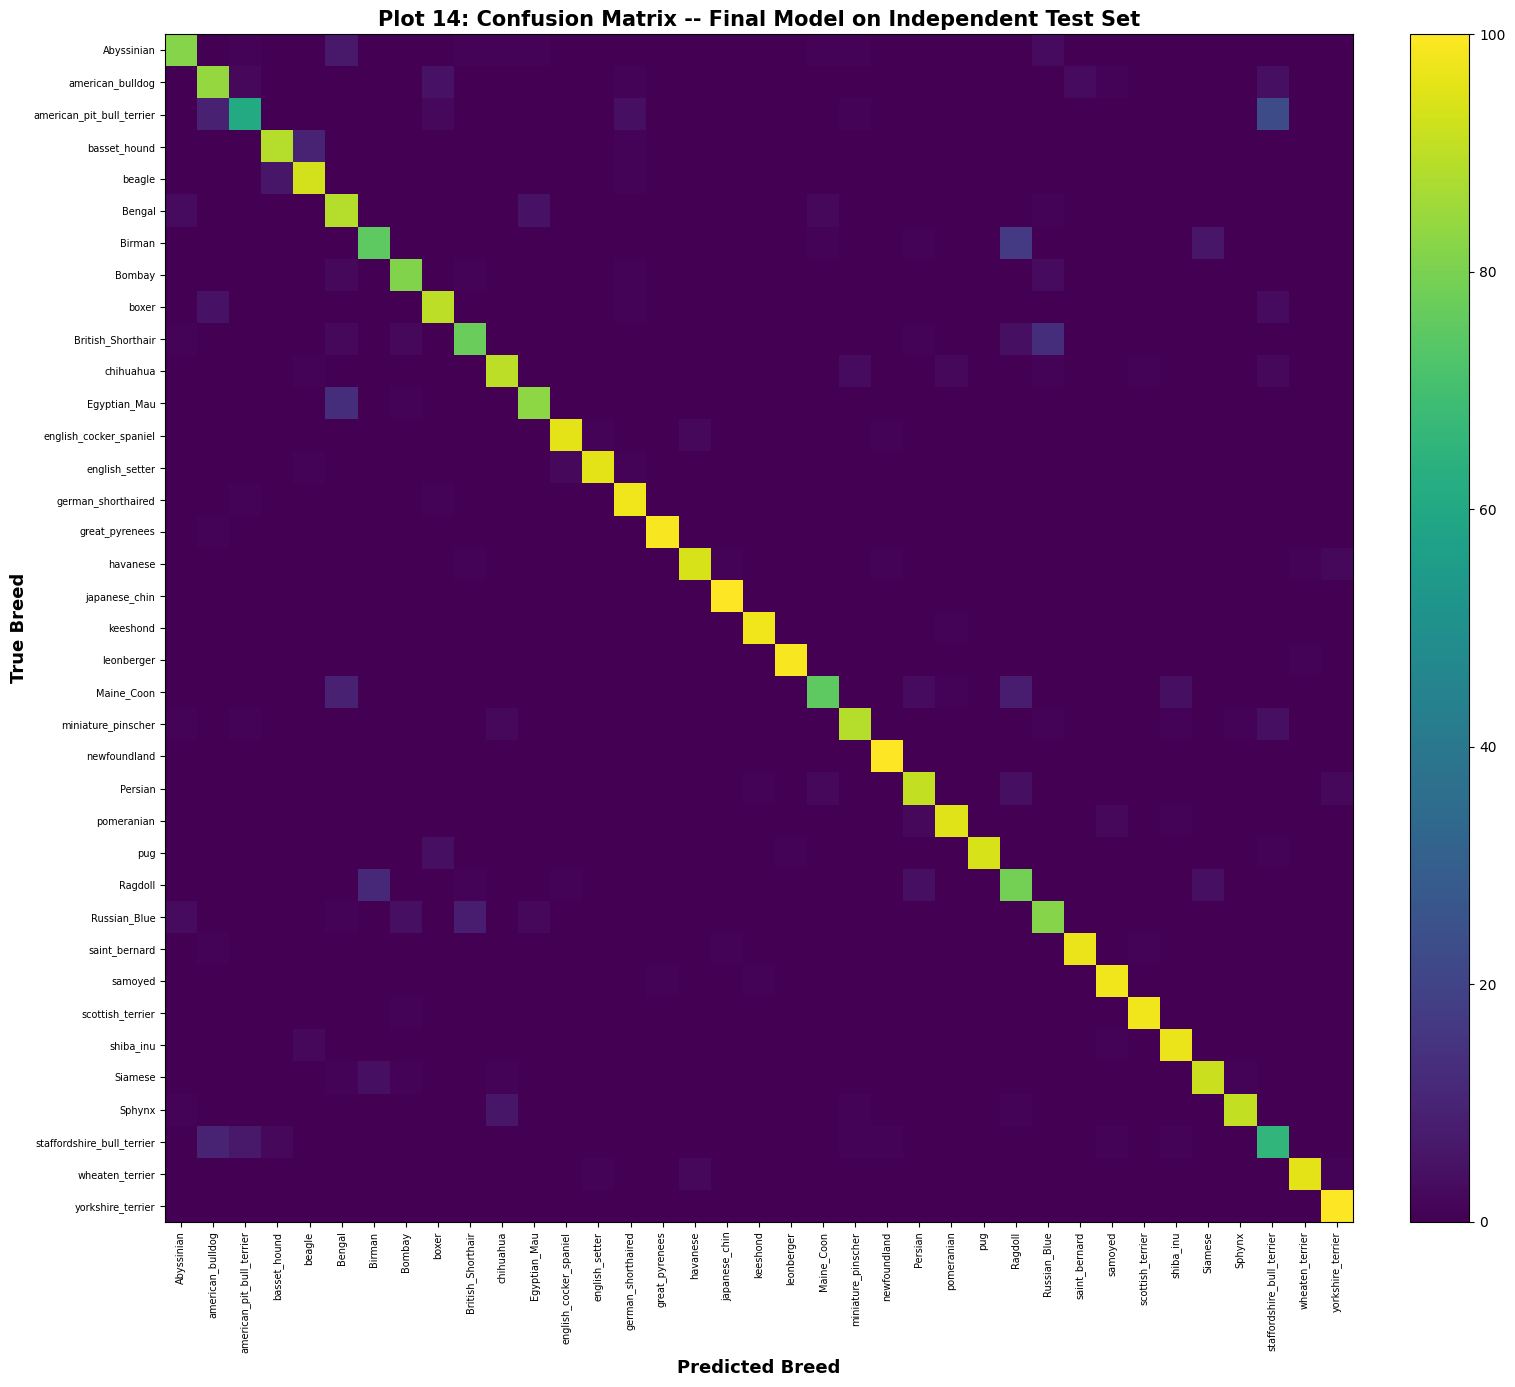

In [44]:
cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="viridis")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(CLASS_NAMES, fontsize=7)
ax.set_xlabel("Predicted Breed", fontweight="bold", fontsize=13)
ax.set_ylabel("True Breed", fontweight="bold", fontsize=13)
ax.set_title("Plot 14: Confusion Matrix -- Final Model on Independent Test Set", fontweight="bold", fontsize=15)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, "08_final_model", "plot14_confusion_matrix.png"),
            dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Automatically derive best/worst-classified breeds and most-confused class pairs from `cm`.
per_class_correct = np.diag(cm)
per_class_total = cm.sum(axis=1)
per_class_acc = np.divide(per_class_correct, per_class_total,
                           out=np.zeros_like(per_class_correct, dtype=float), where=per_class_total > 0)

class_acc_df = pd.DataFrame({"Breed": CLASS_NAMES, "Accuracy": per_class_acc, "N Test Images": per_class_total})
best_classes = class_acc_df.sort_values("Accuracy", ascending=False).head(5)
worst_classes = class_acc_df.sort_values("Accuracy", ascending=True).head(5)
print("Best-classified breeds:"); display(best_classes)
print("Worst-classified breeds:"); display(worst_classes)

# Most-confused pairs: largest off-diagonal counts.
cm_off = cm.copy().astype(float)
np.fill_diagonal(cm_off, 0)
flat_idx = np.dstack(np.unravel_index(np.argsort(-cm_off, axis=None), cm_off.shape))[0]
confused_pairs = []
seen = set()
for i, j in flat_idx:
    if cm_off[i, j] <= 0:
        break
    key = tuple(sorted((i, j)))
    if key in seen:
        continue
    seen.add(key)
    confused_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j] + cm[j, i])))
    if len(confused_pairs) >= 5:
        break
confused_df = pd.DataFrame(confused_pairs, columns=["Breed A", "Breed B", "Combined Confusions"])
print("Most frequently confused breed pairs:"); display(confused_df)

save_text_summary(os.path.join(RESULTS_ROOT, "08_final_model", "confusion_analysis.txt"), [
    "Best-classified breeds:\n" + best_classes.to_string(index=False),
    "\nWorst-classified breeds:\n" + worst_classes.to_string(index=False),
    "\nMost confused breed pairs:\n" + confused_df.to_string(index=False),
])

show_md(auto_inference({
    "What the confusion matrix shows": "per-breed classification performance of the final model on "
        "the untouched independent test set, with darker off-diagonal cells indicating breed pairs "
        "the model frequently confuses",
    "Trend observed": f"the model classifies '{best_classes.iloc[0]['Breed']}' most reliably "
        f"({best_classes.iloc[0]['Accuracy']*100:.1f}% accuracy) while '{worst_classes.iloc[0]['Breed']}' "
        f"is hardest ({worst_classes.iloc[0]['Accuracy']*100:.1f}% accuracy)",
    "Likely reason": "confusions concentrate between visually similar breeds (similar coat pattern, "
        "colour or body shape), which is exactly the kind of fine-grained distinction a frozen or "
        "lightly fine-tuned ImageNet backbone finds hardest to separate",
}))


Best-classified breeds:


,Breed,Accuracy,N Test Images
17,japanese_chin,1.00,100
22,newfoundland,1.00,100
36,yorkshire_terrier,1.00,100
15,great_pyrenees,0.99,100
19,leonberger,0.99,100


Worst-classified breeds:


,Breed,Accuracy,N Test Images
2,american_pit_bull_terrier,0.610000,100
34,staffordshire_bull_terrier,0.741573,89
20,Maine_Coon,0.750000,100
6,Birman,0.750000,100
9,British_Shorthair,0.770000,100


Most frequently confused breed pairs:


,Breed A,Breed B,Combined Confusions
0,american_pit_bull_terrier,staffordshire_bull_terrier,30
1,Birman,Ragdoll,28
2,Egyptian_Mau,Bengal,18
3,British_Shorthair,Russian_Blue,21
4,staffordshire_bull_terrier,american_bulldog,14


**Inference (auto-generated from the actual run above):**

- **What the confusion matrix shows:** per-breed classification performance of the final model on the untouched independent test set, with darker off-diagonal cells indicating breed pairs the model frequently confuses
- **Trend observed:** the model classifies 'japanese_chin' most reliably (100.0% accuracy) while 'american_pit_bull_terrier' is hardest (61.0% accuracy)
- **Likely reason:** confusions concentrate between visually similar breeds (similar coat pattern, colour or body shape), which is exactly the kind of fine-grained distinction a frozen or lightly fine-tuned ImageNet backbone finds hardest to separate

### Plot 15 — Representative Misclassified Test Images

Total misclassified test images: 355 / 3669


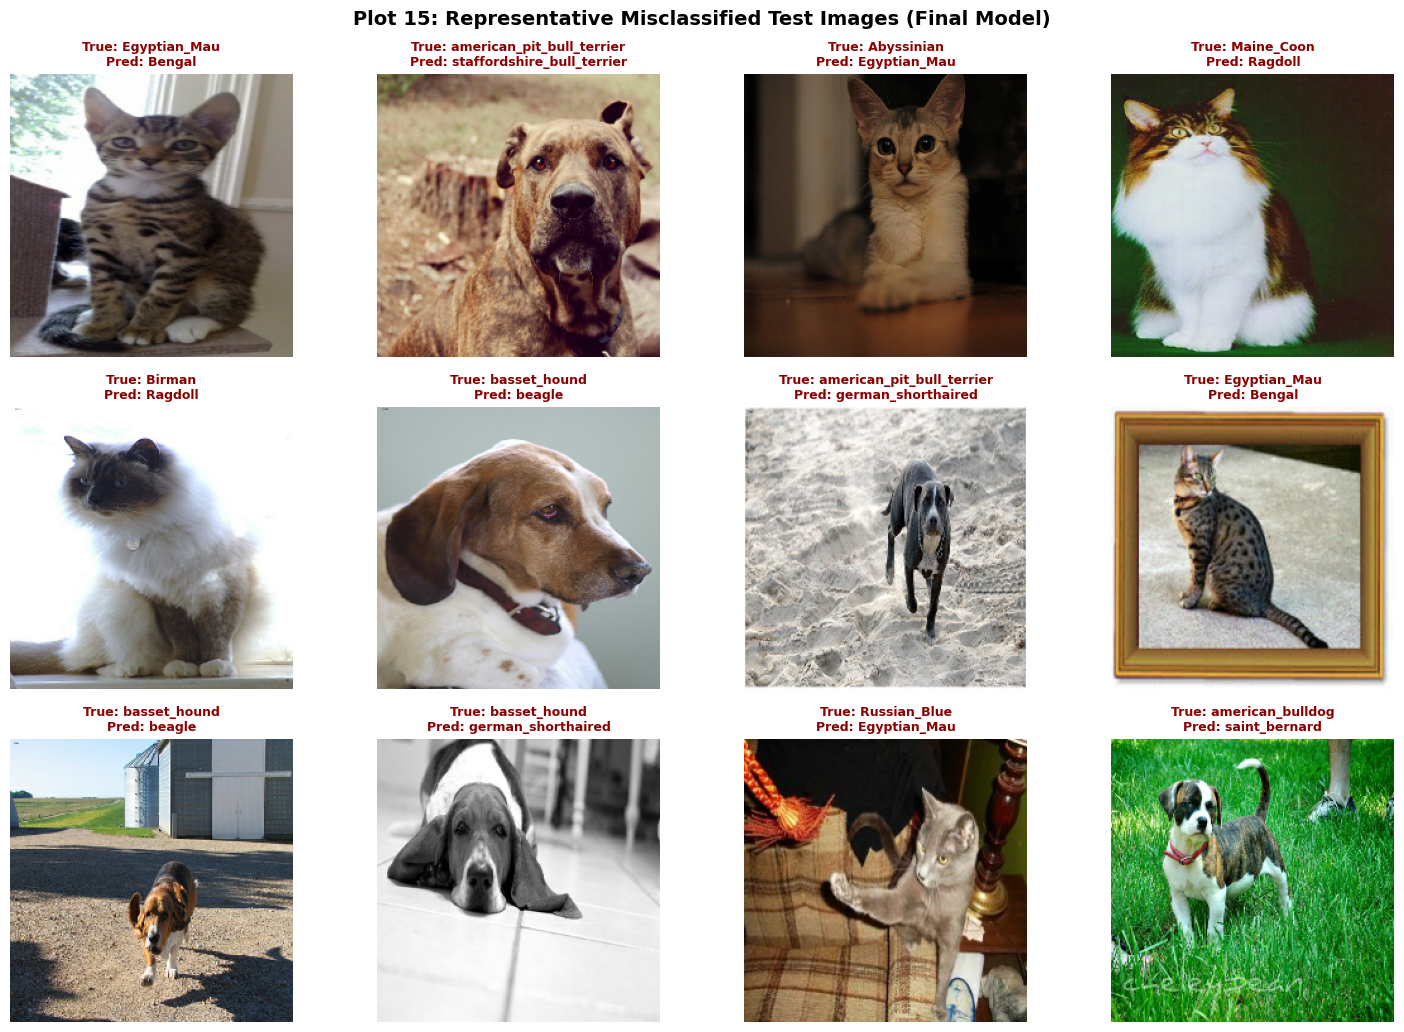

In [46]:
misclassified_idx = np.where(test_preds != y_test)[0]
print(f"Total misclassified test images: {len(misclassified_idx)} / {len(y_test)}")

if len(misclassified_idx) > 0:
    rng_mis = np.random.RandomState(SEED)   # deterministic selection -> reproducible figure
    n_show = min(12, len(misclassified_idx))
    chosen = rng_mis.choice(misclassified_idx, size=n_show, replace=False)

    n_cols = 4
    n_rows = (n_show + n_cols - 1) // n_cols
    plt.figure(figsize=(15, 3.5 * n_rows))
    for i, idx in enumerate(chosen):
        plt.subplot(n_rows, n_cols, i + 1)
        img_sample = get_sample_image_from_array(X_test, idx)
        plt.imshow(img_sample)
        true_cls = CLASS_NAMES[y_test[idx]]
        pred_cls = CLASS_NAMES[test_preds[idx]]
        plt.title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=9, color="darkred", fontweight="bold")
        plt.axis("off")
    plt.suptitle("Plot 15: Representative Misclassified Test Images (Final Model)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_ROOT, "08_final_model", "plot15_misclassified_samples.png"),
                dpi=300, bbox_inches="tight")
    plt.show()


## 17. Task 9 — Overall Results

A single comparison table across the major experiments/configurations of the notebook. Displayed
as a pandas DataFrame in-notebook and also saved as a lightweight human-readable TXT summary
(no CSV files are created, per the assignment constraints).

In [47]:
# ============================================================
# TASK 9 — OVERALL RESULTS COMPARISON
# ============================================================

# Tasks 1, 2 and 4 are controlled single train/validation
# experiments. Task 7 provides the actual 5-fold CV results
# used for model selection.

# ------------------------------------------------------------
# Best results from individual controlled experiments
# ------------------------------------------------------------

best_init_idx = init_results_df["Best Validation Accuracy"].idxmax()
best_init_name = init_results_df.loc[
    best_init_idx, "Configuration"
]
best_init_acc = init_results_df.loc[
    best_init_idx, "Best Validation Accuracy"
]
best_init_time = init_results_df.loc[
    best_init_idx, "Training Time (s)"
]

best_reg_idx = reg_results_df["Best Validation Accuracy"].idxmax()
best_reg_name = reg_results_df.loc[
    best_reg_idx, "Configuration"
]
best_reg_acc = reg_results_df.loc[
    best_reg_idx, "Best Validation Accuracy"
]
best_reg_time = reg_results_df.loc[
    best_reg_idx, "Training Time (s)"
]

best_opt_idx = opt_results_df["Best Validation Accuracy"].idxmax()
best_opt_name = opt_results_df.loc[
    best_opt_idx, "Configuration"
]
best_opt_acc = opt_results_df.loc[
    best_opt_idx, "Best Validation Accuracy"
]
best_opt_time = opt_results_df.loc[
    best_opt_idx, "Training Time (s)"
]


# ------------------------------------------------------------
# 5-fold CV results from Task 7
# ------------------------------------------------------------

c1_res = cv_results["C1_Baseline"]
c2_res = cv_results["C2_Best_Hyperparameters"]
c4_res = cv_results["C4_Fine_Tuned"]


# ------------------------------------------------------------
# Determine which CV configuration was selected
# ------------------------------------------------------------

config_mapping = {
    "C1_Baseline": "1. Baseline",
    "C2_Best_Hyperparameters": "5. Best Hyperparameters",
    "C4_Fine_Tuned": "6. Fine-Tuned Model",
}

# selected_config_name is guaranteed (Task 7, Section 15.1) to be one of C1/C2/C4 only --
# C3 (Feature Extraction) is excluded from final-model selection because Task 9 has no
# dedicated row for it. Fail loudly rather than silently mislabeling if that ever changes.
assert selected_config_name in config_mapping, (
    f"Unexpected selected_config_name '{selected_config_name}' -- Task 9's six-row table has "
    "no mapping for it. Update config_mapping or the SELECTION_CANDIDATES list in Section 15.1."
)
selected_row_label = config_mapping[selected_config_name]


# ------------------------------------------------------------
# Six required configurations
# ------------------------------------------------------------

overall_six_rows = [

    {
        "Configuration": "1. Baseline",
        "CV Accuracy": f"{c1_res['mean_accuracy']:.4f}",
        "SD": f"{c1_res['std_accuracy']:.4f}",
        "Test Accuracy": (
            f"{test_accuracy:.4f}"
            if selected_row_label == "1. Baseline"
            else "N/A"
        ),
        "Training Time (s)": f"{c1_res['mean_training_time']:.1f}",
    },

    {
        "Configuration": "2. Best Initialization",
        "CV Accuracy": f"{best_init_acc:.4f}*",
        "SD": "N/A (Single Split)",
        "Test Accuracy": "N/A",
        "Training Time (s)": f"{best_init_time:.1f}",
    },

    {
        "Configuration": "3. Best Regularization",
        "CV Accuracy": f"{best_reg_acc:.4f}*",
        "SD": "N/A (Single Split)",
        "Test Accuracy": "N/A",
        "Training Time (s)": f"{best_reg_time:.1f}",
    },

    {
        "Configuration": "4. Best Optimizer",
        "CV Accuracy": f"{best_opt_acc:.4f}*",
        "SD": "N/A (Single Split)",
        "Test Accuracy": "N/A",
        "Training Time (s)": f"{best_opt_time:.1f}",
    },

    {
        "Configuration": "5. Best Hyperparameters",
        "CV Accuracy": f"{c2_res['mean_accuracy']:.4f}",
        "SD": f"{c2_res['std_accuracy']:.4f}",
        "Test Accuracy": (
            f"{test_accuracy:.4f}"
            if selected_row_label == "5. Best Hyperparameters"
            else "N/A"
        ),
        "Training Time (s)": f"{c2_res['mean_training_time']:.1f}",
    },

    {
        "Configuration": "6. Fine-Tuned Model",
        "CV Accuracy": f"{c4_res['mean_accuracy']:.4f}",
        "SD": f"{c4_res['std_accuracy']:.4f}",
        "Test Accuracy": (
            f"{test_accuracy:.4f}"
            if selected_row_label == "6. Fine-Tuned Model"
            else "N/A"
        ),
        "Training Time (s)": f"{c4_res['mean_training_time']:.1f}",
    },
]


# ------------------------------------------------------------
# Display table
# ------------------------------------------------------------

overall_results_df = pd.DataFrame(overall_six_rows)

display(overall_results_df)


# ------------------------------------------------------------
# Explain provenance clearly
# ------------------------------------------------------------

show_md(
    f"""
### Task 9 — Overall Results

Configurations **1, 5 and 6** report genuine 5-fold cross-validation
mean accuracy and standard deviation obtained in Task 7.

Configurations **2, 3 and 4** are marked with (*) because their
reported accuracy comes from the controlled single train/validation
experiments in Tasks 1, 2 and 4 rather than 5-fold cross-validation.

Only the selected final configuration (**{selected_row_label}**) is
evaluated on the independent test set. The remaining configurations
therefore show **N/A** for Test Accuracy to preserve test-set isolation.
"""
)


# ------------------------------------------------------------
# Save Task 9 results
# ------------------------------------------------------------

save_text_summary(
    os.path.join(
        RESULTS_ROOT,
        "09_overall_results",
        "task9_overall_results.txt"
    ),
    [
        overall_results_df.to_string(index=False),
        (
            "\nProvenance: Configurations 1, 5 and 6 report "
            "5-fold CV mean accuracy and SD. Configurations 2, 3 "
            "and 4 report single-split validation accuracy. "
            f"Only {selected_row_label} was evaluated on the "
            "independent test set."
        )
    ]
)

print("\n✓ Task 9 overall-results table generated.")
print("✓ Exactly six required configurations included.")
print("✓ Test Accuracy reported only for the selected final configuration.")
print("✓ Test-set isolation preserved.")


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time (s)
0,1. Baseline,0.9141,0.0061,0.9032,44.0
1,2. Best Initialization,0.9212*,N/A (Single Split),N/A,56.6
2,3. Best Regularization,0.9090*,N/A (Single Split),N/A,49.1
3,4. Best Optimizer,0.9062*,N/A (Single Split),N/A,48.6
4,5. Best Hyperparameters,0.9096,0.0102,N/A,39.4
5,6. Fine-Tuned Model,0.8869,0.0114,N/A,52.5



### Task 9 — Overall Results

Configurations **1, 5 and 6** report genuine 5-fold cross-validation
mean accuracy and standard deviation obtained in Task 7.

Configurations **2, 3 and 4** are marked with (*) because their
reported accuracy comes from the controlled single train/validation
experiments in Tasks 1, 2 and 4 rather than 5-fold cross-validation.

Only the selected final configuration (**1. Baseline**) is
evaluated on the independent test set. The remaining configurations
therefore show **N/A** for Test Accuracy to preserve test-set isolation.



✓ Task 9 overall-results table generated.
✓ Exactly six required configurations included.
✓ Test Accuracy reported only for the selected final configuration.
✓ Test-set isolation preserved.


## 18. Task 10 — Additional Exercise

Two genuinely new configurations, evaluated with the same `run_stratified_cv()` 5-fold engine used
in Task 7, and compared against the Task 7-selected configuration.

- **New-A:** learning rate 5e-5, dropout 0.4, batch size 16, partial fine-tuning of the last 40
  backbone layers.
- **New-B:** learning rate 1e-3, dropout 0.2, L2 5e-4, batch size 64, frozen backbone.

In [48]:
NEW_CONFIGS = {
    "New-A": dict(initializer="he", dropout=0.4, l2_reg=0.0, unfreeze_layers=40,
                  optimizer_name="adam", learning_rate=5e-5),
    "New-B": dict(initializer="he", dropout=0.2, l2_reg=5e-4, unfreeze_layers=0,
                  optimizer_name="adam", learning_rate=1e-3),
}
NEW_BATCH_SIZES = {"New-A": 16, "New-B": 64}

# Sanity check: both new combinations must genuinely differ from the Task-7-selected configuration.
for _name, _cfg in NEW_CONFIGS.items():
    _same_as_selected = all(selected_config.get(k) == v for k, v in _cfg.items())
    assert not _same_as_selected, f"{_name} is identical to the selected configuration -- must differ."
print("Both New-A and New-B confirmed to differ from the Task-7-selected configuration.")

additional_cv_results = {}
for name, cfg in NEW_CONFIGS.items():
    print(f"\n=== 5-Fold CV: {name} ===")
    additional_cv_results[name] = run_stratified_cv(
        cfg, train_indices, y_train, X=X_trainpool, n_splits=5, epochs=CV_EPOCHS, batch_size=NEW_BATCH_SIZES[name]
    )
    r = additional_cv_results[name]
    print(f"  Mean +/- SD: {r['mean_accuracy']:.4f} +/- {r['std_accuracy']:.4f}")

# Merge in the Task-7-selected configuration's own CV result for a fair side-by-side comparison.
selected_label_for_comparison = f"{selected_config_name} (Task 7 selection)"
additional_cv_results[selected_label_for_comparison] = selected_cv_result

additional_cv_table = pd.DataFrame({
    name: {**{f"Fold {i+1}": s for i, s in enumerate(r["fold_scores"])},
           "Mean Accuracy": r["mean_accuracy"], "Std Dev": r["std_accuracy"],
           "Mean Training Time (s)": r["mean_training_time"]}
    for name, r in additional_cv_results.items()
}).T
display(additional_cv_table)
save_text_summary(os.path.join(RESULTS_ROOT, "10_additional_exercise", "task10_additional_cv_results.txt"),
                   [additional_cv_table.to_string()])


Both New-A and New-B confirmed to differ from the Task-7-selected configuration.

=== 5-Fold CV: New-A ===


2026-08-29 18:27:08.387242: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:27:08.538916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:27:08.676195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 1/5: val_acc=0.8778  time=68.5s
  Fold 2/5: val_acc=0.8964  time=59.4s
  Fold 3/5: val_acc=0.8913  time=58.7s
  Fold 4/5: val_acc=0.8930  time=59.9s


2026-08-29 18:31:52.359694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:31:52.496592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 5/5: val_acc=0.8759  time=66.6s
  Mean +/- SD: 0.8869 +/- 0.0084

=== 5-Fold CV: New-B ===


2026-08-29 18:33:00.046565: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:33:00.186567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 1/5: val_acc=0.9032  time=48.5s
  Fold 2/5: val_acc=0.9185  time=40.1s
  Fold 3/5: val_acc=0.9117  time=39.3s
  Fold 4/5: val_acc=0.9083  time=39.7s


2026-08-29 18:36:29.500238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-29 18:36:29.640418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 5/5: val_acc=0.9082  time=48.2s
  Mean +/- SD: 0.9100 +/- 0.0050


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Std Dev,Mean Training Time (s)
New-A,0.877759,0.896435,0.891341,0.893039,0.875850,0.886885,0.008414,62.630331
New-B,0.903226,0.918506,0.911715,0.908319,0.908163,0.909986,0.005047,43.149715
C1_Baseline (Task 7 selection),0.908319,0.925297,0.915110,0.911715,0.909864,0.914061,0.006057,43.961786


### Additional Comparison Plot — New Configurations vs Selected Configuration

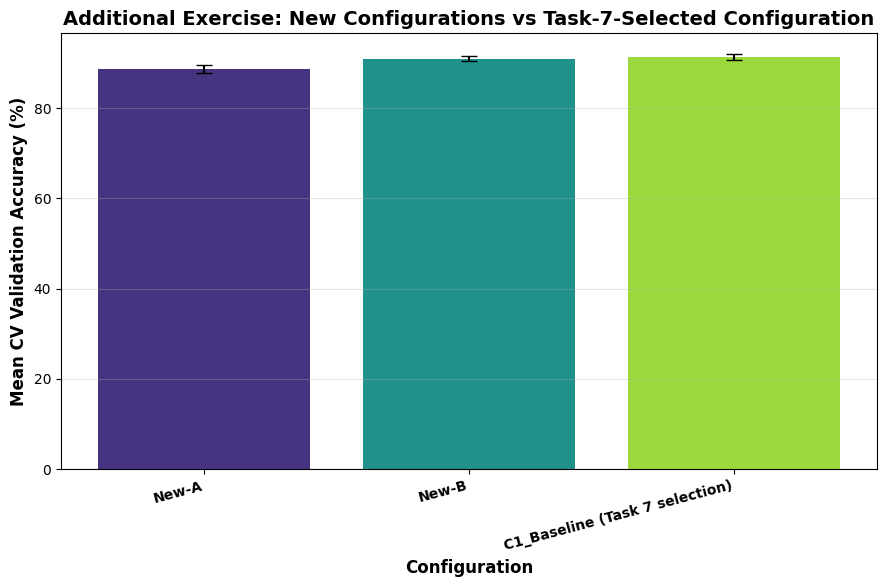

**Inference (auto-generated from the actual run above):**

- **Best of the two new configurations:** New-B (mean CV accuracy = 0.9100)
- **Task 7-selected configuration accuracy:** 0.9141
- **Verdict:** New-B was NOT clearly preferable to the Task-7-selected configuration on this run.

**Inference (auto-generated from the actual run above):**

- **Accuracy comparison:** New-A=0.8869, New-B=0.9100, selected (C1_Baseline)=0.9141
- **Standard deviation comparison:** New-A SD=0.0084, New-B SD=0.0050, selected SD=0.0061
- **Computational cost comparison:** New-A=62.6s/fold, New-B=43.1s/fold, selected=44.0s/fold
- **Relative to final test performance:** the Task-8 final model (independent test accuracy 0.9032) was trained using the Task-7-selected configuration, not New-A/New-B; New-B was NOT clearly preferable to it on CV accuracy alone, so it was not chosen for final retraining

In [49]:
names = list(additional_cv_results.keys())
means = np.array([additional_cv_results[n]["mean_accuracy"] for n in names]) * 100
stds  = np.array([additional_cv_results[n]["std_accuracy"] for n in names]) * 100
plot_bar_categorical(
    names, means, xlabel="Configuration", ylabel="Mean CV Validation Accuracy (%)",
    title="Additional Exercise: New Configurations vs Task-7-Selected Configuration",
    filename=os.path.join(RESULTS_ROOT, "10_additional_exercise", "additional_comparison_plot.png"),
    yerr=stds,
)

best_new = max(NEW_CONFIGS.keys(), key=lambda n: additional_cv_results[n]["mean_accuracy"])
best_new_acc = additional_cv_results[best_new]["mean_accuracy"]
selected_acc_in_this_table = additional_cv_results[selected_label_for_comparison]["mean_accuracy"]
verdict = "was preferable to" if best_new_acc > selected_acc_in_this_table else "was NOT clearly preferable to"
show_md(auto_inference({
    "Best of the two new configurations": f"{best_new} (mean CV accuracy = {best_new_acc:.4f})",
    "Task 7-selected configuration accuracy": f"{selected_acc_in_this_table:.4f}",
    "Verdict": f"{best_new} {verdict} the Task-7-selected configuration on this run.",
}))

_best_new_time = additional_cv_results[best_new]["mean_training_time"]
_selected_time = additional_cv_results[selected_label_for_comparison]["mean_training_time"]
show_md(auto_inference({
    "Accuracy comparison": f"New-A={additional_cv_results['New-A']['mean_accuracy']:.4f}, "
        f"New-B={additional_cv_results['New-B']['mean_accuracy']:.4f}, "
        f"selected ({selected_config_name})={selected_acc_in_this_table:.4f}",
    "Standard deviation comparison": f"New-A SD={additional_cv_results['New-A']['std_accuracy']:.4f}, "
        f"New-B SD={additional_cv_results['New-B']['std_accuracy']:.4f}, "
        f"selected SD={cv_results[selected_config_name]['std_accuracy']:.4f}",
    "Computational cost comparison": f"New-A={additional_cv_results['New-A']['mean_training_time']:.1f}s/fold, "
        f"New-B={additional_cv_results['New-B']['mean_training_time']:.1f}s/fold, "
        f"selected={_selected_time:.1f}s/fold",
    "Relative to final test performance": f"the Task-8 final model (independent test accuracy "
        f"{test_accuracy:.4f}) was trained using the Task-7-selected configuration, not New-A/New-B; "
        f"{best_new} {verdict} it on CV accuracy alone, so it was not chosen for final retraining",
}))


## 19. Output Verification

Checks that every expected plot and result directory actually exists before packaging the ZIP.

In [50]:
EXPECTED_REQUIRED_PLOTS = [
    "01_initialization/plot1_training_loss.png",
    "01_initialization/plot2_validation_accuracy.png",
    "02_regularization/plot3_accuracy.png",
    "02_regularization/plot4_loss.png",
    "03_batch_normalization/plot5_bn_comparison.png",
    "04_optimizers/plot6_training_loss.png",
    "04_optimizers/plot7_validation_accuracy.png",
    "05_hyperparameter_tuning/plot8_learning_rate.png",
    "05_hyperparameter_tuning/plot9_batch_size.png",
    "05_hyperparameter_tuning/plot10_dropout.png",
    "06_transfer_learning/plot11_feature_vs_finetuning.png",
    "06_transfer_learning/plot12_loss_comparison.png",
    "07_cross_validation/plot13_cv_accuracy.png",
    "08_final_model/plot14_confusion_matrix.png",
    "08_final_model/plot15_misclassified_samples.png",
]

ADDITIONAL_REPORT_PLOTS = [
    "09_overall_results/dataset_samples.png",
    "10_additional_exercise/additional_comparison_plot.png",
]

missing_required = []
for rel_path in EXPECTED_REQUIRED_PLOTS:
    full_path = os.path.join(RESULTS_ROOT, rel_path)
    status = "OK" if os.path.exists(full_path) else "MISSING"
    if status == "MISSING":
        missing_required.append(full_path)
    print(f"[{status}] (Required) {rel_path}")

for rel_path in ADDITIONAL_REPORT_PLOTS:
    full_path = os.path.join(RESULTS_ROOT, rel_path)
    status = "OK" if os.path.exists(full_path) else "NOT PRESENT"
    print(f"[{status}] (Additional) {rel_path}")

print("\nResult directories:")
for d in SUBDIRS:
    full_dir = os.path.join(RESULTS_ROOT, d)
    status = "OK" if os.path.isdir(full_dir) else "MISSING"
    print(f"[{status}] {full_dir}")

if missing_required:
    print(f"\nWARNING: {len(missing_required)} required plot(s) missing:", missing_required)
else:
    print(f"\nAll {len(EXPECTED_REQUIRED_PLOTS)} required plots and all result directories are present and verified.")


[OK] (Required) 01_initialization/plot1_training_loss.png
[OK] (Required) 01_initialization/plot2_validation_accuracy.png
[OK] (Required) 02_regularization/plot3_accuracy.png
[OK] (Required) 02_regularization/plot4_loss.png
[OK] (Required) 03_batch_normalization/plot5_bn_comparison.png
[OK] (Required) 04_optimizers/plot6_training_loss.png
[OK] (Required) 04_optimizers/plot7_validation_accuracy.png
[OK] (Required) 05_hyperparameter_tuning/plot8_learning_rate.png
[OK] (Required) 05_hyperparameter_tuning/plot9_batch_size.png
[OK] (Required) 05_hyperparameter_tuning/plot10_dropout.png
[OK] (Required) 06_transfer_learning/plot11_feature_vs_finetuning.png
[OK] (Required) 06_transfer_learning/plot12_loss_comparison.png
[OK] (Required) 07_cross_validation/plot13_cv_accuracy.png
[OK] (Required) 08_final_model/plot14_confusion_matrix.png
[OK] (Required) 08_final_model/plot15_misclassified_samples.png
[OK] (Additional) 09_overall_results/dataset_samples.png
[OK] (Additional) 10_additional_exercis

## 20. Package All Outputs (Final ZIP)

Zips the entire `Experiment_5_Results/` folder (all 15 PNG plots plus the lightweight TXT result
summaries -- no CSV files) into `Experiment_5_Results.zip`. On Kaggle, the zip is written to the working directory and can be downloaded from the
notebook's Output pane.

In [51]:
zip_path = "Experiment_5_Results.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(RESULTS_ROOT):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, ".")
            zf.write(full_path, arcname)

print(f"Created {zip_path} ({os.path.getsize(zip_path)/1e6:.2f} MB)")

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    print("Not running in Colab -- the zip file is available at:", os.path.abspath(zip_path))

Created Experiment_5_Results.zip (10.06 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
from IPython.display import FileLink

zip_path = "Experiment_5_Results.zip"

print(f"ZIP ready: {os.path.abspath(zip_path)}")
display(FileLink(zip_path))

ZIP ready: /kaggle/working/Experiment_5_Results.zip


/kaggle/working/Experiment_5_Results.zip

In [1]:
from PIL import Image
import os

SOURCE = r"C:\Users\YOUR_NAME\Downloads\Experiment_5_Results"
OUTPUT = r"C:\Users\YOUR_NAME\Downloads\Experiment_5_Results_Optimized"

MAX_WIDTH = 1800

for root, dirs, files in os.walk(SOURCE):
    for file in files:
        if not file.lower().endswith(".png"):
            continue

        src = os.path.join(root, file)

        rel = os.path.relpath(root, SOURCE)
        out_dir = os.path.join(OUTPUT, rel)
        os.makedirs(out_dir, exist_ok=True)

        out = os.path.join(out_dir, file)

        img = Image.open(src)

        # Convert to RGB/RGBA safely
        if img.mode not in ("RGB", "RGBA"):
            img = img.convert("RGBA")

        # Downscale only if unnecessarily large
        if img.width > MAX_WIDTH:
            new_height = int(img.height * MAX_WIDTH / img.width)
            img = img.resize(
                (MAX_WIDTH, new_height),
                Image.Resampling.LANCZOS
            )

        img.save(
            out,
            format="PNG",
            optimize=True,
            compress_level=9
        )

        old_size = os.path.getsize(src) / 1024
        new_size = os.path.getsize(out) / 1024

        print(
            f"{file}: "
            f"{old_size:.0f} KB -> {new_size:.0f} KB"
        )

print("\nDone.")


Done.
